In [2]:
import os
os.environ.setdefault("OBJC_DISABLE_INITIALIZE_FORK_SAFETY", "YES")
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("OMP_NUM_THREADS", "1")

import pandas as pd
import numpy as np
from pathlib import Path

def _find_project_root() -> Path:
    for base in [Path.cwd(), Path.cwd().parent, Path("..").resolve()]:
        if (base / "data" / "influencer_profiles.csv").exists():
            return base.resolve()
    raise FileNotFoundError(
        "data/influencer_profiles.csv bulunamadı. "
        "Notebook'u TezBitirme/notebooks klasöründen açın veya cwd=TezBitirme kullanın."
    )

ROOT_DIR = _find_project_root()
DATA_DIR = ROOT_DIR / "data"

PROFILES_CSV = DATA_DIR / "influencer_profiles.csv"
POSTS_CSV    = DATA_DIR / "influencer_posts.csv"
COMMENTS_CSV = DATA_DIR / "influencer_comments.csv"  # opsiyonel, olmasa da devam eder

print(f"Proje kökü : {ROOT_DIR}")
print(f"Veri klasörü: {DATA_DIR}")

for path, label in [
    (PROFILES_CSV, "Profil"),
    (POSTS_CSV,    "Post"),
    (COMMENTS_CSV, "Yorum (opsiyonel)"),
]:
    status = "✅" if path.exists() else "⚠️ yok"
    print(f"  {status} {label}: {path.name}")

if not PROFILES_CSV.exists():
    raise FileNotFoundError(f"Profil CSV bulunamadı: {PROFILES_CSV}")
if not POSTS_CSV.exists():
    raise FileNotFoundError(f"Post CSV bulunamadı: {POSTS_CSV}")

# Yorum dosyası varsa yükle, yoksa boş DataFrame
if COMMENTS_CSV.exists():
    df_comments = pd.read_csv(COMMENTS_CSV)
    print(f"✅ Yorum tablosu yüklendi: {len(df_comments)} yorum")
else:
    df_comments = pd.DataFrame(columns=['influencer_name', 'comment_text', 'comment_likes'])
    print("⚠️ Yorum verisi yok — sentiment analizi sadece caption üzerinden çalışacak")

# 1. Profil verisini yükle
df_inf = pd.read_csv(PROFILES_CSV)
print(f"\n✅ Profil tablosu yüklendi: {len(df_inf)} fenomen")

# 2. Post verisini yükle
df_post = pd.read_csv(POSTS_CSV)
print(f"✅ Post tablosu yüklendi: {len(df_post)} gönderi")

# 3. Kontrol
print("\n--- Profil Sütunları ---")
print(df_inf.columns.tolist())
print("\n--- Post Sütunları ---")
print(df_post.columns.tolist())

df_inf.head()

Proje kökü : /Users/zeynepyildirim/Desktop/TezBitirme
Veri klasörü: /Users/zeynepyildirim/Desktop/TezBitirme/data
  ✅ Profil: influencer_profiles.csv
  ✅ Post: influencer_posts.csv
  ⚠️ yok Yorum (opsiyonel): influencer_comments.csv
⚠️ Yorum verisi yok — sentiment analizi sadece caption üzerinden çalışacak

✅ Profil tablosu yüklendi: 135 fenomen
✅ Post tablosu yüklendi: 13344 gönderi

--- Profil Sütunları ---
['influencer_name', 'display_name', 'post_count', 'avg_likes', 'avg_comments', 'avg_views', 'total_likes', 'total_comments', 'account_type', 'country', 'followers_at_date', 'oldest_followers', 'FGR', 'first_post', 'last_post', 'category']

--- Post Sütunları ---
['influencer_name', 'post_date', 'likes', 'comments', 'shares', 'views', 'post_reach', 'caption', 'is_branded_content', 'content_type', 'hashtags']


,influencer_name,display_name,post_count,avg_likes,avg_comments,avg_views,total_likes,total_comments,account_type,country,followers_at_date,oldest_followers,FGR,first_post,last_post,category
0,alatokell,Ala Tokel,100,7202.51,35.60,874913.03,720251,3560,creator,TR,4374565,3499652,-41.40,2025-05-09 13:10:37,2026-05-17 12:19:43,NaN
1,ardaguler,Arda Güler,100,1832874.36,12692.31,32475484.92,183287436,1269231,creator,TR,162377425,129901940,-64.65,2024-06-01 22:37:25,2026-05-18 18:49:03,NaN
2,ardasaatci,Arda Saatçi,100,245645.14,1457.13,5572785.69,24564514,145713,creator,TR,27863928,22291143,688.15,2025-05-06 14:12:55,2026-05-10 22:43:29,NaN
3,ardaturan,Arda Turan,100,181803.63,1980.63,4163297.36,18180363,198063,creator,TR,20816487,16653189,0.00,2020-09-27 20:25:28,2026-04-11 10:41:42,NaN
4,ardaturkmen,arda turkmen,100,8680.77,110.98,452526.89,868077,11098,creator,TR,2262634,1810108,-10.97,2025-09-18 16:47:19,2026-05-18 15:56:12,NaN


In [3]:
# Hashtag boşsa 'diğer' ata
df_post['category_new'] = df_post['hashtags'].fillna('diğer')

# Gereksiz sütunları kaldır — Meta verisinde Post ID / Influencer Handle yok
# ama varsa diye güvenli bırakıyoruz
cols_to_drop = ['Post ID', 'Influencer Handle', 'is_branded_content', 'content_type']
df_post.drop(columns=[c for c in cols_to_drop if c in df_post.columns], inplace=True)

df_post.head(20)

,influencer_name,post_date,likes,comments,shares,views,post_reach,caption,hashtags,category_new
0,alatokell,2025-05-09 13:10:37,9676,35,0,2124315,2124315,Bu ara favorim olan her şey ektedir.\nreklam,NaN,diğer
1,alatokell,2025-05-10 15:59:33,14475,28,0,1101069,1101069,Seoul sen benim beynimin içisin\nreklam,NaN,diğer
2,alatokell,2025-05-11 12:54:53,12603,24,0,768471,768471,Feeling blueeeee\nreklam,NaN,diğer
3,alatokell,2025-05-12 14:11:18,4835,14,0,617140,617140,Serving looks in the land of kimchi & K-dramas...,reklam,reklam
4,alatokell,2025-05-13 14:25:05,10916,19,0,767733,767733,Proof I didn’t dream it 🩵\nreklam,NaN,diğer
5,alatokell,2025-05-14 18:27:05,3864,19,0,774105,774105,my happy place💘 @individuelgeneve_kr_official ...,reklam,reklam
6,alatokell,2025-05-21 15:56:03,1124,22,0,710884,710884,"Dolgun ve parlak saçlar için tek ihtiyacım, ağ...",herkeskendinebaksın işbirliği,herkeskendinebaksın işbirliği
7,alatokell,2025-05-24 13:58:58,1218,14,0,730690,730690,Parlayanlar kulübüne hoş geldiniz!\nBugün yeni...,isbirligi,isbirligi
8,alatokell,2025-05-27 21:00:28,5888,15,0,1924602,1924602,"Tara’yla bir date çıkışı biraz sarhoşken, voic...",reklam,reklam
9,alatokell,2025-06-01 10:32:10,2823,11,0,1030726,1030726,Biz hem tırnak hem makyaj stüdyosuyuz. Hatırla...,reklam,reklam


In [4]:
# Meta verisinde post tablosunda zaten Followers yok ama güvenli kontrol
if 'Followers' in df_post.columns:
    df_post.drop(columns=['Followers'], inplace=True)

print("--- Post Eksik Değerler ---")
print(df_post.isnull().sum())
print("\n--- Profil Eksik Değerler ---")
print(df_inf.isnull().sum())

--- Post Eksik Değerler ---
influencer_name       0
post_date             0
likes                 0
comments              0
shares                0
views                 0
post_reach            0
caption            1553
hashtags           8089
category_new          0
dtype: int64

--- Profil Eksik Değerler ---
influencer_name        0
display_name           0
post_count             0
avg_likes              0
avg_comments           0
avg_views              0
total_likes            0
total_comments         0
account_type           0
country                0
followers_at_date      0
oldest_followers       0
FGR                    0
first_post             0
last_post              0
category             135
dtype: int64


In [5]:
# Sentetik verideki gereksiz sütunlar — Meta'da zaten yok ama errors='ignore' güvenli
cols_to_remove = ['Eng. (Avg.)', 'Eng. (Auth.)', 'instagram name']
df_post.drop(columns=cols_to_remove, errors='ignore', inplace=True)

# country post tablosunda yok, profiles'ta var — orada düzelt
if 'country' in df_post.columns:
    df_post['country'] = df_post['country'].fillna('unknown')

# Profiles'taki country zaten 'TR' — eksik varsa doldur
if 'country' in df_inf.columns:
    df_inf['country'] = df_inf['country'].fillna('unknown')

In [6]:
# Değişken adların standartizasyonu
df_post.columns = (
    df_post.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[\s\.\(\)%]+', '_', regex=True)
)

# Kontrol — sütun isimlerini yazdır
print("Post sütunları:", df_post.columns.tolist())
print("Profil sütunları:", df_inf.columns.tolist())


Post sütunları: ['influencer_name', 'post_date', 'likes', 'comments', 'shares', 'views', 'post_reach', 'caption', 'hashtags', 'category_new']
Profil sütunları: ['influencer_name', 'display_name', 'post_count', 'avg_likes', 'avg_comments', 'avg_views', 'total_likes', 'total_comments', 'account_type', 'country', 'followers_at_date', 'oldest_followers', 'FGR', 'first_post', 'last_post', 'category']


In [13]:
import re

# 1. Veri birleştirme
merged = pd.merge(df_inf, df_post, on='influencer_name', how='inner')
merged['post_date'] = pd.to_datetime(merged['post_date'], errors='coerce')
merged = merged.sort_values(['influencer_name', 'post_date'])

# 2. Hashtag temizleme
def clean_tags(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-zA-ZçğıöşüÇĞİÖŞÜ ]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

merged['clean_tags'] = merged['hashtags'].apply(clean_tags)

# 3. Kategori anahtar kelimeleri
category_keywords = {
    'moda': [
    'fashion','style','ootd','beauty','makeup','outfit','moda','kombin',
    'güzellik','stil','giyim','kıyafet','trend','makyaj','aksesuar',
    'gardırop','butik','koleksiyon','tasarım','elbise','ayakkabı',
    'çanta','takı','skin','krem','parfüm','saç','saçbakımı','ciltbakımı',
    'skincare','sephora','sephoratürkiye','elidor','makyajı','rujum',
    'fondöten','kaş','göz'
],
    'spor': [
        'fitness','gym','workout','running','yoga','sport','spor','antrenman',
        'egzersiz','koşu','futbol','basketbol','voleybol','yüzme','bisiklet',
        'pilates','crossfit','maç','turnuva','transfer','goal','gol','saha',
        'stadyum','forma','atlet','sporcu','lig','şampiyonluk','squat','dumbbell'
    ],
    'teknoloji': [
        'tech','gadgets','innovation','ai','coding','developer','teknoloji',
        'yazılım','telefon','uygulama','bilgisayar','internet','sosyalmedya',
        'dijital','youtube','podcast','kamera','drone','review','inceleme',
        'unboxing','galaxy','samsung','iphone','apple','deepseek','esim',
        'airalo','galaxyzflip','uzay','robot','bilim','veri','algoritma','yazılımcı'
    ],
    'anne-bebek': [
        'baby','momlife','parenting','kids','motherhood','anne','bebek',
        'çocuk','hamilelik','doğum','emzirme','oyuncak','okul','aile',
        'annelik','babalık','çocukbakımı','kreş','gebelik','çocukgelişimi'
    ],
    'oyun': [
        'gaming','game','gamer','playstation','xbox','stream','oyun',
        'esports','twitch','minecraft','valorant','pubg','lol','zula',
        'türkçeyayın','yayın','canlı','streamer','youtuber','elraenn'
    ],
    'yemek': [
        'food','recipe','cook','delicious','yummy','yemek','tarif','lezzet',
        'mutfak','restoran','cafe','kahve','tatlı','börek','pasta','çorba',
        'gurme','şef','pişirme','nefis','kahvaltı','akşamyemeği','atıştırmalık',
        'vegan','glutensiz','brownie','foccacia','burrito','smashburger',
        'mutfağı','ramazan','tarifi','lezzetli','soğan','domates','zeytinyağı'
    ],
    'lifestyle': [
        'lifestyle','yaşamtarzı','selfcare','rutin','minimalizm','motivasyon',
        'kişiselgelişim','günlük','vlog','hayat','sabah','gece','ev','dekor',
        'organizing','temizlik','alışveriş','haul','favori','öneri','tavsiye',
        'günüm','rutini','challenge','trending','keşfet','paylaşım'
    ],
    'seyahat': [
        'travel','seyahat','gezi','tatil','explore','wanderlust','kamp',
        'roadtrip','otel','uçak','istanbul','ankara','izmir','kapadokya',
        'bodrum','antalya','paris','dubai','bali','keşif','rota',
        'maldivler','phuket','rome','barcelona','berlin','amsterdam'
    ],
    'egitim': [
        'eğitim','education','öğrenme','learning','üniversite','sınav',
        'kitap','akademik','ders','öğrenci','yks','lgs','tyt','ayt',
        'öğretmen','okul','araştırma','makale','kurs','sertifika',
        'konferans','seminer','webinar','sunum'
    ],
    'saglik': [
        'sağlık','health','beslenme','meditasyon','diyet','wellness',
        'psikoloji','doktor','hastane','ilaç','vitamin','kilo','zayıflama',
        'detoks','uyku','stres','terapi','zihinsel','magnezyum','takviye',
        'supplement','protein','kalori','diyetisyen','fizyoterapi','psikiyatri'
    ],
    'evcilhayvan': [
        'köpek','kedi','pet','hayvan','evcil','puppy','dog','cat','kuş',
        'akvaryum','veteriner','pati','tüylü','sevimli','animal'
    ]
}

def detect_category(text):
    if not text:
        return 'diğer'
    text = text.lower()
    # Önce spesifik kategoriler, sonra genel olanlar
    priority_order = [
        'yemek', 'spor', 'oyun', 'teknoloji', 'anne-bebek',
        'evcilhayvan', 'egitim', 'saglik', 'seyahat', 'moda', 'lifestyle'
    ]
    for category in priority_order:
        for kw in category_keywords[category]:
            if kw in text:
                return category
    return 'diğer'

# Hashtag + caption birleştirerek uygula
merged['combined_text'] = (
    merged['clean_tags'] + ' ' + merged['caption'].fillna('').str.lower()
)
merged['auto_category'] = merged['combined_text'].apply(detect_category)

# 4. Fenomen özet tablosu oluştur
influencer_summary = merged.groupby('influencer_name').agg(
    total_likes      = ('likes', 'sum'),
    total_comments   = ('comments', 'sum'),
    total_shares     = ('shares', 'sum'),
    avg_likes        = ('likes', 'mean'),
    avg_comments     = ('comments', 'mean'),
    avg_views        = ('views', 'mean'),
    post_count       = ('post_date', 'count'),
    avg_post_reach   = ('post_reach', 'mean'),
    first_post       = ('post_date', 'min'),
    last_post        = ('post_date', 'max'),
    category         = ('auto_category', 'first'),
    country          = ('country', 'first'),
    account_type     = ('account_type', 'first'),
).reset_index()

influencer_summary['eng_auth'] = (
    influencer_summary['total_likes'] + influencer_summary['total_comments']
)

# 5. engagement_rate — views bazlı
influencer_summary['engagement_rate'] = (
    (influencer_summary['avg_likes'] + influencer_summary['avg_comments']) /
    influencer_summary['avg_views'].replace(0, np.nan)
) * 100
influencer_summary['engagement_rate'] = influencer_summary['engagement_rate'].fillna(0)

# FGR — profiles tablosundan al
fgr_map = df_inf.set_index('influencer_name')['FGR'].to_dict()
influencer_summary['FGR'] = influencer_summary['influencer_name'].map(fgr_map).fillna(0)

# FGR sıfır olanlar için account_type bazlı taban değer
_fgr_floor = {'business': 3.0, 'creator': 1.5, 'personal': 0.5}
_zero_fgr = influencer_summary['FGR'] == 0
influencer_summary.loc[_zero_fgr, 'FGR'] = (
    influencer_summary.loc[_zero_fgr, 'account_type'].map(_fgr_floor).fillna(0.5)
)

# Aktif gün sayısı
influencer_summary['day_active'] = (
    influencer_summary['last_post'] - influencer_summary['first_post']
).dt.days.fillna(1).clip(lower=1)

# Aylık gönderi sıklığı
influencer_summary['posts_per_month'] = (
    influencer_summary['post_count'] /
    (influencer_summary['day_active'] / 30)
).fillna(0)

# latest_followers / oldest_followers — avg_views proxy
influencer_summary['latest_followers'] = influencer_summary['avg_views'] * 5
influencer_summary['oldest_followers'] = influencer_summary['avg_views'] * 4

# 6. clean_tags_all
clean_tags_per_influencer = (
    merged.groupby('influencer_name')['clean_tags']
    .apply(lambda x: ' '.join(x.dropna().unique()))
    .reset_index()
)
clean_tags_per_influencer.columns = ['influencer_name', 'clean_tags_all']

influencer_summary = influencer_summary.merge(
    clean_tags_per_influencer, on='influencer_name', how='left'
)
influencer_summary['clean_tags_all'] = influencer_summary['clean_tags_all'].fillna('')

import sys
from pathlib import Path as _Path
_pdir = _Path('..').resolve() / 'pipeline'
if str(_pdir) not in sys.path:
    sys.path.insert(0, str(_pdir))
from category_seeds import append_seed_to_tags

influencer_summary['clean_tags_all'] = influencer_summary.apply(
    lambda r: append_seed_to_tags(r['clean_tags_all'], r.get('category', '')),
    axis=1,
)

# 7. Kontrol
print("✅ Cell 6 tamamlandı")
print(f"Fenomen sayısı: {len(influencer_summary)}")
print(f"\nKategori dağılımı:")
print(influencer_summary['category'].value_counts())
print(f"\nÖrnek değerler:")
print(influencer_summary[['influencer_name','engagement_rate','FGR',
                'posts_per_month','avg_views']].head(3))

✅ Cell 6 tamamlandı
Fenomen sayısı: 135

Kategori dağılımı:
category
diğer          70
lifestyle      14
yemek          13
moda            9
spor            7
teknoloji       6
oyun            5
anne-bebek      4
evcilhayvan     3
seyahat         3
saglik          1
Name: count, dtype: int64

Örnek değerler:
  influencer_name  engagement_rate     FGR  posts_per_month    avg_views
0       alatokell         0.827295  -41.40         8.064516    874913.03
1       ardaguler         5.682953  -64.65         4.195804  32475484.92
2      ardasaatci         4.434089  688.15         8.130081   5572785.69


In [18]:
# ============================================================
# NFS — production ile aynı modül (pipeline/nfs_scoring.py)
# ============================================================
import sys
from pathlib import Path
import importlib
import nfs_scoring
importlib.reload(nfs_scoring)
from nfs_scoring import compute_nfs

_pipeline_dir = Path("..").resolve() / "pipeline"
if str(_pipeline_dir) not in sys.path:
    sys.path.insert(0, str(_pipeline_dir))

from nfs_scoring import compute_nfs

influencer_summary, nfs_model, nfs_artifacts = compute_nfs(influencer_summary, verbose=True)

influencer_summary[
    ['influencer_name', 'category', 'account_type',
     'engagement_rate', 'FGR', 'posts_per_month', 'nfs_label', 'NFS']
].sort_values('NFS', ascending=False).head(10)

✅ NFS — Korelasyon bazlı ağırlıklı skor
   Özellikler: ['engagement_rate', 'FGR', 'posts_per_month']
   Korelasyon bazlı ağırlıklar: {'engagement_rate': 0.9106, 'FGR': 0.0309, 'posts_per_month': 0.0585}
   Train R² (engagement_rate ~ NFS): 0.743


,influencer_name,category,account_type,engagement_rate,FGR,posts_per_month,nfs_label,NFS
89,murattatikofficial,diğer,personal,177.865661,-44.29,3.102378,91.12,91.12
20,caglaralkac,diğer,business,171.457349,3.00,1.239157,87.85,87.85
132,zuzu_mutfakta,yemek,business,48.466043,3.00,1.633987,24.89,24.89
106,senolozkosee,diğer,creator,41.034519,1.50,2.647838,21.09,21.09
88,muratsakaoglu,diğer,creator,40.769125,1.50,0.872340,20.94,20.94
61,iammuratf,diğer,creator,37.022946,1.50,2.538071,19.04,19.04
66,londongyd,diğer,business,24.054329,-43.35,2.638522,12.37,12.37
25,canercindoruk,oyun,creator,13.145681,1.50,1.252610,6.80,6.80
116,tugkangonultas,diğer,business,12.599971,3.00,1.484414,6.53,6.53
82,modamerve,teknoloji,business,0.214594,30.74,750.000000,6.05,6.05


In [20]:
#SFS KISMI

from sentence_transformers import SentenceTransformer
from numpy.linalg import norm

# macOS MPS çökmesini önlemek için CPU
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2", device="cpu")

# Her fenomen için metin oluştur (hashtag + caption birleştirme)
def build_influencer_text(group):
    tags = ' '.join(group['clean_tags'].dropna().unique())
    captions = ' '.join(group['caption'].dropna().unique())
    return (tags + ' ' + captions).strip()

influencer_texts = (
    merged.groupby('influencer_name')
    .apply(lambda g: build_influencer_text(g[['clean_tags', 'caption']]))
    .reset_index()
)
influencer_texts.columns = ['influencer_name', 'influencer_text']

# Kategori seed prepend
import sys
from pathlib import Path as _Path
_pdir = _Path('..').resolve() / 'pipeline'
if str(_pdir) not in sys.path:
    sys.path.insert(0, str(_pdir))
from category_seeds import prepend_seed_to_text
_cat_map = influencer_summary.set_index('influencer_name')['category'].to_dict()
influencer_texts['influencer_text'] = influencer_texts.apply(
    lambda r: prepend_seed_to_text(r['influencer_text'], _cat_map.get(r['influencer_name'], ''), repeat=3),
    axis=1,
)

print(f"✅ {len(influencer_texts)} fenomen için metin oluşturuldu")
print(f"\nÖrnek metin ({influencer_texts['influencer_name'].iloc[0]}):")
print(influencer_texts['influencer_text'].iloc[0][:300] + "...")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ 135 fenomen için metin oluşturuldu

Örnek metin (alatokell):
lifestyle yasam gunluk vlog motivasyon inspiration minimalizm dekorasyon ev lifestyle yasam gunluk vlog motivasyon inspiration minimalizm dekorasyon ev lifestyle yasam gunluk vlog motivasyon inspiration minimalizm dekorasyon ev reklam herkeskendinebaksın işbirliği isbirligi işbirliği oralbio isbirli...


/var/folders/2c/kq641z3x3m159d0gc_tx6f280000gn/T/ipykernel_44057/2034477539.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: build_influencer_text(g[['clean_tags', 'caption']]))


In [21]:
brand_texts = {
    "spor_kampanyasi": """
    Spor giyim markasıyız. Fitness, spor salonu, koşu, yoga ve aktif yaşam tarzı
    içerikleri üreten fenomenlerle çalışmak istiyoruz. Antrenman rutinleri, spor
    beslenme önerileri, motivasyon içerikleri ve sağlıklı yaşam paylaşımları
    yapan içerik üreticileri arıyoruz.
    """,

    "moda_kampanyasi": """
    Moda ve güzellik markasıyız. Stil önerileri, kombin paylaşımları, makyaj
    ve güzellik içerikleri üreten fenomenlerle çalışmak istiyoruz. Sokak modası,
    trend takibi, aksesuar ve kıyafet incelemeleri yapan içerik üreticileri arıyoruz.
    """,

    "teknoloji_kampanyasi": """
    Teknoloji ve elektronik markasıyız. Cihaz incelemeleri, yazılım geliştirme,
    yapay zeka, kodlama ve dijital inovasyon içerikleri üreten fenomenlerle
    çalışmak istiyoruz. Ürün karşılaştırmaları ve teknoloji haberleri paylaşan
    içerik üreticileri arıyoruz.
    """,

    "yemek_kampanyasi": """
    Gıda ve mutfak markasıyız. Yemek tarifleri, restoran incelemeleri, sağlıklı
    beslenme ve mutfak içerikleri üreten fenomenlerle çalışmak istiyoruz.
    Ev yemekleri, gurme deneyimler ve pratik tarifler paylaşan içerik
    üreticileri arıyoruz.
    """,

    "annebebek_kampanyasi": """
    Anne ve bebek ürünleri markasıyız. Annelik deneyimleri, bebek bakımı,
    çocuk gelişimi ve aile yaşamı içerikleri üreten fenomenlerle çalışmak
    istiyoruz. Hamilelik süreci, emzirme, bebek beslenmesi ve ebeveynlik
    önerileri paylaşan içerik üreticileri arıyoruz.
    """,

    "oyun_kampanyasi": """
    Oyun ve e-spor markasıyız. Oyun incelemeleri, canlı yayın, e-spor turnuvaları
    ve gaming setup içerikleri üreten fenomenlerle çalışmak istiyoruz.
    Strateji oyunları, FPS oyunları ve oyun dünyası haberleri paylaşan
    içerik üreticileri arıyoruz.
    """
}

inf_texts = influencer_texts['influencer_text'].astype(str).tolist()
influencer_embeddings = model.encode(inf_texts, show_progress_bar=True)

#Cosine similarity
def cosine_sim(a, b):
    return np.dot(a, b) / (norm(a) * norm(b) + 1e-10)

# 4. Her marka için tüm fenomenlerle benzerlik hesapla
for campaign_name, brand_text in brand_texts.items():
    brand_embedding = model.encode([brand_text])[0]

    similarities = [cosine_sim(emb, brand_embedding) for emb in influencer_embeddings]
    influencer_texts[f'sim_{campaign_name}'] = similarities

# 5. influencer_summary'ye ekle
influencer_summary = influencer_summary.merge(
    influencer_texts[['influencer_name'] + [f'sim_{c}' for c in brand_texts.keys()]],
    on='influencer_name', how='left'
)

# 6. Sonuçları göster - spor kampanyası için en uygun 10 fenomen
print("\n🏆 Spor kampanyası için en uygun 10 fenomen:")
influencer_summary[['influencer_name', 'category', 'NFS', 'sim_spor_kampanyasi']]\
    .sort_values('sim_spor_kampanyasi', ascending=False).head(10)


Batches:   0%|          | 0/5 [00:00<?, ?it/s]


🏆 Spor kampanyası için en uygun 10 fenomen:


,influencer_name,category,NFS,sim_spor_kampanyasi
41,dilarakocakiyiyasam,spor,1.65,0.600005
46,ebrukaradumanofficial,spor,0.85,0.543268
102,refikaguzellik,spor,0.27,0.534118
48,ebrusalli,spor,0.12,0.500879
44,ebruakel,spor,0.80,0.499145
33,cilgin_fikirlerr,diğer,0.85,0.434085
134,zynpzeze,lifestyle,0.91,0.427373
127,zeynepceltek_adana,saglik,0.35,0.417979
51,edaerdem14,diğer,1.94,0.405797
26,canereler,diğer,1.76,0.400017


In [22]:
from transformers import pipeline

# Türkçe duygu analiz modeli
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="savasy/bert-base-turkish-sentiment-cased",
    device=-1,
)

def get_sentiment(text):
    if pd.isna(text) or str(text).strip() == "":
        return "NEUTRAL", 0.0, 0.0

    try:
        result = sentiment_pipeline(str(text)[:512])[0]
        label = result['label']
        score = result['score']

        # Madde 4 düzeltmesi: signed_score
        # positive → +score, negative → -score, neutral → 0
        if label == 'positive':
            signed = score
        elif label == 'negative':
            signed = -score
        else:
            signed = 0.0

        return label, score, signed
    except:
        return "NEUTRAL", 0.0, 0.0

merged[['sentiment_label', 'sentiment_score', 'signed_sentiment']] = merged['caption'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

print(f"✅ {len(merged)} post için duygu analizi tamamlandı")
print("\n--- Duygu Dağılımı ---")
print(merged['sentiment_label'].value_counts())
print(merged['sentiment_label'].value_counts(normalize=True).round(3) * 100)
print("\n--- Signed Sentiment Örnek ---")
print(merged[['caption', 'sentiment_label', 'sentiment_score', 'signed_sentiment']].head(5).to_string())

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ 13344 post için duygu analizi tamamlandı

--- Duygu Dağılımı ---
sentiment_label
positive    10560
NEUTRAL      1553
negative     1231
Name: count, dtype: int64
sentiment_label
positive    79.1
NEUTRAL     11.6
negative     9.2
Name: proportion, dtype: float64

--- Signed Sentiment Örnek ---
                                                   caption sentiment_label  sentiment_score  signed_sentiment
0             Bu ara favorim olan her şey ektedir.\nreklam        positive         0.992676          0.992676
1                  Seoul sen benim beynimin içisin\nreklam        positive         0.991502          0.991502
2                                 Feeling blueeeee\nreklam        positive         0.984888          0.984888
3  Serving looks in the land of kimchi & K-dramas\n#reklam        positive         0.968594          0.968594
4                        Proof I didn’t dream it 🩵\nreklam        positive         0.991975          0.991975


In [23]:
# Sentiment sonuçlarını cache'le — tekrar çalıştırmamak için
merged[['influencer_name', 'post_date', 'sentiment_label', 
        'sentiment_score', 'signed_sentiment']].to_csv(
    DATA_DIR / 'sentiment_cache.csv', index=False
)
print("✅ Sentiment cache kaydedildi")

✅ Sentiment cache kaydedildi


In [26]:
sentiment_summary = merged.groupby('influencer_name').apply(
    lambda g: pd.Series({
        'total_posts':         len(g),
        'positive_count':      (g['sentiment_label'] == 'positive').sum(),
        'negative_count':      (g['sentiment_label'] == 'negative').sum(),
        'positive_ratio':      (g['sentiment_label'] == 'positive').mean() * 100,
        'negative_ratio':      (g['sentiment_label'] == 'negative').mean() * 100,
        'avg_sentiment_score': g['sentiment_score'].mean(),
        'avg_signed_sentiment': g['signed_sentiment'].mean(),  # Madde 4 — negatifler eksi
    })
).reset_index()

influencer_summary = influencer_summary.merge(
    sentiment_summary[['influencer_name', 'positive_ratio', 'negative_ratio',
                        'avg_sentiment_score', 'avg_signed_sentiment']],
    on='influencer_name', how='left'
)

print("✅ Duygu analizi fenomen bazına çevrildi\n")
influencer_summary[['influencer_name', 'category', 'positive_ratio',
                     'negative_ratio', 'avg_sentiment_score', 'avg_signed_sentiment']]\
    .sort_values('avg_signed_sentiment', ascending=False).head(10)

✅ Duygu analizi fenomen bazına çevrildi



/var/folders/2c/kq641z3x3m159d0gc_tx6f280000gn/T/ipykernel_44057/534867723.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sentiment_summary = merged.groupby('influencer_name').apply(


,influencer_name,category,positive_ratio,negative_ratio,avg_sentiment_score,avg_signed_sentiment
46,ebrukaradumanofficial,spor,100.0,0.0,0.996934,0.996934
82,modamerve,teknoloji,100.0,0.0,0.996020,0.996020
51,edaerdem14,diğer,100.0,0.0,0.990974,0.990974
55,evamurati,moda,100.0,0.0,0.990651,0.990651
60,hey_bones_animals,evcilhayvan,99.0,0.0,0.987160,0.987160
78,mesutavsar,teknoloji,98.0,0.0,0.976133,0.976133
110,seymasubasi,diğer,99.0,1.0,0.993077,0.976057
30,cansuakinn,diğer,99.0,1.0,0.989019,0.969080
108,sevvalsam,evcilhayvan,99.0,1.0,0.979862,0.967034
2,ardasaatci,diğer,99.0,0.0,0.963232,0.963232


In [35]:
# Puanlama bazlı etiketleme — daha dengeli dağılım için
nfs_p50  = influencer_summary['NFS'].quantile(0.50)
nfs_p75  = influencer_summary['NFS'].quantile(0.75)

sfs_cols_list = [f'sim_{c}' for c in campaign_columns.keys()]
sfs_all  = influencer_summary[sfs_cols_list].values.flatten()
sfs_p50  = pd.Series(sfs_all).quantile(0.50)
sfs_p75  = pd.Series(sfs_all).quantile(0.75)

pos_p33  = influencer_summary['positive_ratio'].quantile(0.33)

print(f"NFS  — p50: {nfs_p50:.2f}, p75: {nfs_p75:.2f}")
print(f"SFS  — p50: {sfs_p50:.3f}, p75: {sfs_p75:.3f}")
print(f"POS  — p33: {pos_p33:.1f}")

rows = []

for _, inf in influencer_summary.iterrows():
    for campaign_name, sim_col in campaign_columns.items():

        sfs       = inf[sim_col]
        nfs       = inf['NFS']
        pos_ratio = inf['positive_ratio']
        signed    = inf['avg_signed_sentiment']

        # Her kriter için puan ver (0-3 arası toplam)
        puan = 0
        if sfs >= sfs_p50 and nfs >= nfs_p50 and pos_ratio >= pos_p33:
            label = 'uygun'
        elif sfs < 0.05 or nfs < influencer_summary['NFS'].quantile(0.10):
            label = 'uygun_degil'
        else:
            label = 'orta'

        rows.append({
            'influencer_name':      inf['influencer_name'],
            'campaign':             campaign_name,
            'category':             inf['category'],
            'account_type':         inf['account_type'],
            'engagement_rate':      inf['engagement_rate'],
            'FGR':                  inf['FGR'],
            'posts_per_month':      inf['posts_per_month'],
            'NFS':                  nfs,
            'SFS':                  sfs,
            'positive_ratio':       pos_ratio,
            'negative_ratio':       inf['negative_ratio'],
            'avg_sentiment_score':  inf['avg_sentiment_score'],
            'avg_signed_sentiment': signed,
            'label':                label
        })

df_model = pd.DataFrame(rows)

print(f"\n✅ Model veri seti oluşturuldu: {len(df_model)} satır")
print("\n--- Etiket Dağılımı ---")
print(df_model['label'].value_counts())
print(df_model['label'].value_counts(normalize=True).round(3) * 100)

NFS  — p50: 1.14, p75: 1.94
SFS  — p50: 0.183, p75: 0.268
POS  — p33: 80.0

✅ Model veri seti oluşturuldu: 810 satır

--- Etiket Dağılımı ---
label
orta           503
uygun_degil    199
uygun          108
Name: count, dtype: int64
label
orta           62.1
uygun_degil    24.6
uygun          13.3
Name: proportion, dtype: float64


=== Logistic Regression Sonuçları ===

              precision    recall  f1-score   support

        orta       0.86      0.55      0.67       100
       uygun       0.39      0.77      0.52        22
 uygun_degil       0.61      0.82      0.70        40

    accuracy                           0.65       162
   macro avg       0.62      0.72      0.63       162
weighted avg       0.73      0.65      0.66       162

5-Fold CV F1 (weighted): 0.583 ± 0.022


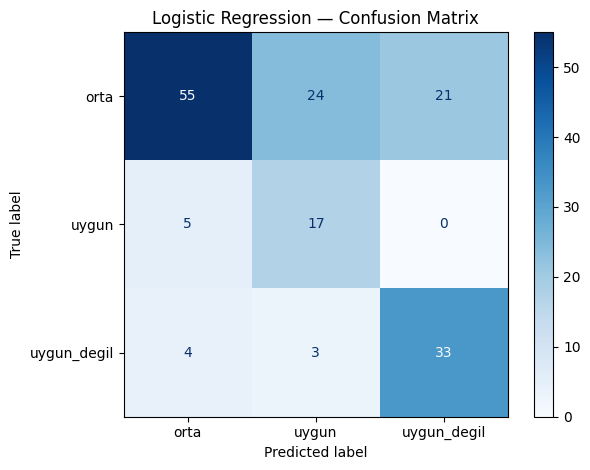

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import pandas as pd

# Feature ve hedef
cat_cols = ['category', 'account_type', 'campaign']
num_cols = ['engagement_rate', 'FGR', 'posts_per_month', 'NFS', 'SFS',
            'positive_ratio', 'negative_ratio', 'avg_sentiment_score',
            'avg_signed_sentiment']

X = df_model[num_cols + cat_cols]
y = df_model['label']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocessing pipeline — encoding leakage'ı önlemek için pipeline içinde
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=3000,
        class_weight='balanced',
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

print("=== Logistic Regression Sonuçları ===\n")
print(classification_report(y_test, y_pred_lr))

# CV — pipeline içinde encoding olduğu için leakage yok
cv_scores = cross_val_score(lr_pipeline, X, y, cv=5, scoring='f1_weighted')
print(f"5-Fold CV F1 (weighted): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr, labels=lr_pipeline.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_pipeline.classes_)
disp.plot(cmap='Blues')
plt.title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

=== Random Forest Sonuçları ===

              precision    recall  f1-score   support

        orta       0.96      0.99      0.98       100
       uygun       0.95      0.91      0.93        22
 uygun_degil       1.00      0.95      0.97        40

    accuracy                           0.97       162
   macro avg       0.97      0.95      0.96       162
weighted avg       0.97      0.97      0.97       162

5-Fold CV F1 (weighted): 0.919 ± 0.033


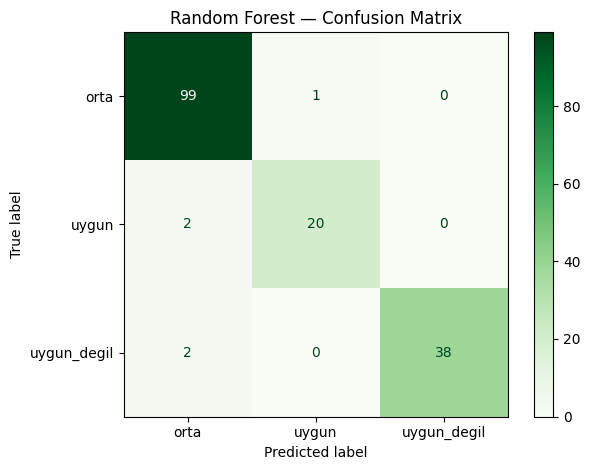

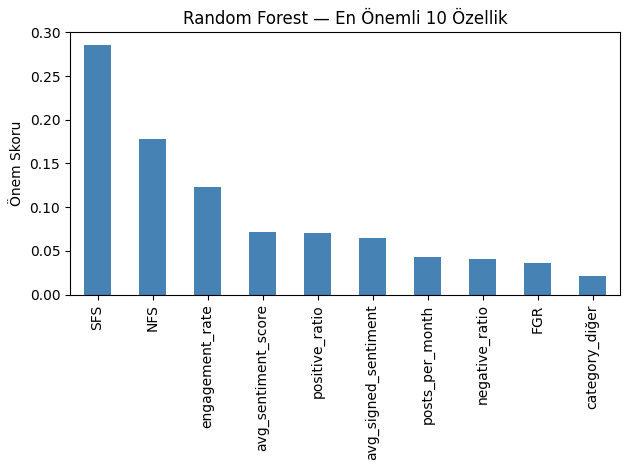


En önemli 10 özellik:
SFS                     0.285771
NFS                     0.177487
engagement_rate         0.122825
avg_sentiment_score     0.071969
positive_ratio          0.070303
avg_signed_sentiment    0.064780
posts_per_month         0.042549
negative_ratio          0.040826
FGR                     0.036339
category_diğer          0.021732
dtype: float64

En önemli 10 özellik:
SFS                     0.285771
NFS                     0.177487
engagement_rate         0.122825
avg_sentiment_score     0.071969
positive_ratio          0.070303
avg_signed_sentiment    0.064780
posts_per_month         0.042549
negative_ratio          0.040826
FGR                     0.036339
category_diğer          0.021732
dtype: float64


In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Pipeline — LR ile aynı preprocessor
preprocessor_rf = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('model', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print("=== Random Forest Sonuçları ===\n")
print(classification_report(y_test, y_pred_rf))

# CV — leakage yok
cv_scores_rf = cross_val_score(rf_pipeline, X, y, cv=5, scoring='f1_weighted')
print(f"5-Fold CV F1 (weighted): {cv_scores_rf.mean():.3f} ± {cv_scores_rf.std():.3f}")

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=rf_pipeline.classes_)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_pipeline.classes_)
disp_rf.plot(cmap='Greens')
plt.title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()

# Özellik önemi — preprocessor'dan feature isimlerini al
rf_model_step = rf_pipeline.named_steps['model']
ohe_features = rf_pipeline.named_steps['preprocessor']\
    .named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
all_features = num_cols + ohe_features

feat_imp = pd.Series(
    rf_model_step.feature_importances_,
    index=all_features
).sort_values(ascending=False).head(10)

feat_imp.plot(kind='bar', color='steelblue')
plt.title("Random Forest — En Önemli 10 Özellik")
plt.ylabel("Önem Skoru")
plt.tight_layout()
plt.show()

print("\nEn önemli 10 özellik:")
print(feat_imp)

print("\nEn önemli 10 özellik:")
print(feat_imp)

In [41]:
pip install imbalanced-learn --break-system-packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imbalanced-learn]

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


=== Random Forest 2 (SMOTE) Sonuçları ===

              precision    recall  f1-score   support

        orta       0.99      0.99      0.99       100
       uygun       0.95      0.95      0.95        22
 uygun_degil       1.00      1.00      1.00        40

    accuracy                           0.99       162
   macro avg       0.98      0.98      0.98       162
weighted avg       0.99      0.99      0.99       162

5-Fold CV F1 (weighted): 0.917 ± 0.031


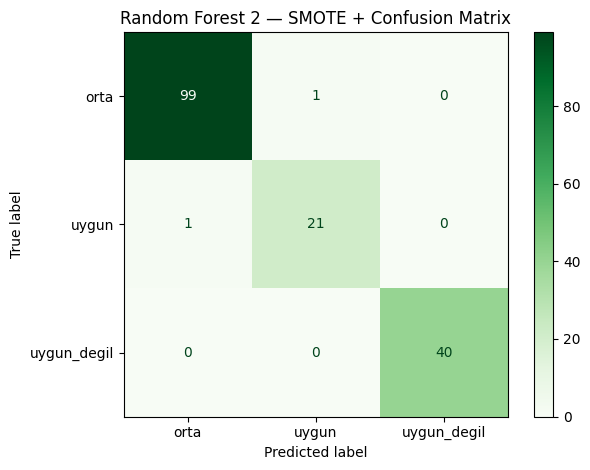

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt

preprocessor_rf2 = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# SMOTE ile dengeleme — Madde 8
rf2_pipeline = ImbPipeline([
    ('preprocessor', preprocessor_rf2),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced_subsample',
        max_depth=None,
        min_samples_leaf=1,
        random_state=42
    ))
])

rf2_pipeline.fit(X_train, y_train)
y_pred_rf2 = rf2_pipeline.predict(X_test)

print("=== Random Forest 2 (SMOTE) Sonuçları ===\n")
print(classification_report(y_test, y_pred_rf2))

cv_scores_rf2 = cross_val_score(rf2_pipeline, X, y, cv=5, scoring='f1_weighted')
print(f"5-Fold CV F1 (weighted): {cv_scores_rf2.mean():.3f} ± {cv_scores_rf2.std():.3f}")

cm_rf2 = confusion_matrix(y_test, y_pred_rf2, labels=rf2_pipeline.classes_)
disp_rf2 = ConfusionMatrixDisplay(confusion_matrix=cm_rf2, display_labels=rf2_pipeline.classes_)
disp_rf2.plot(cmap='Greens')
plt.title("Random Forest 2 — SMOTE + Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
pip install imbalanced-learn --break-system-packages

Etiket sıralaması: ['orta' 'uygun' 'uygun_degil']
=== XGBoost Sonuçları ===

              precision    recall  f1-score   support

        orta       1.00      1.00      1.00       100
       uygun       1.00      1.00      1.00        22
 uygun_degil       1.00      1.00      1.00        40

    accuracy                           1.00       162
   macro avg       1.00      1.00      1.00       162
weighted avg       1.00      1.00      1.00       162

5-Fold CV F1 (weighted): 0.960 ± 0.028


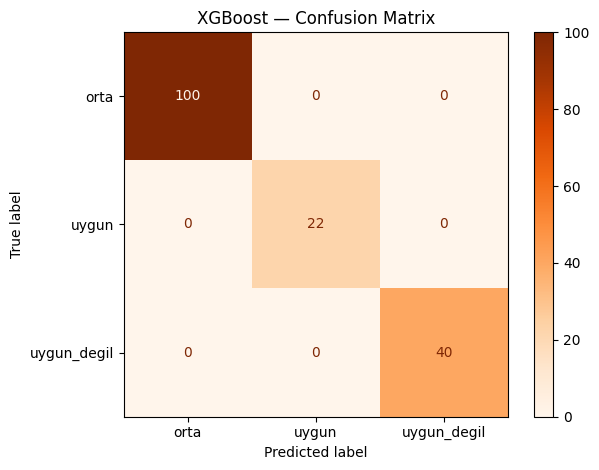

In [47]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# XGBoost sayısal etiket gerekiyor — tüm y için fit et
le = LabelEncoder()
y_enc = le.fit_transform(y)
y_train_enc = le.transform(y_train)
y_test_enc = le.transform(y_test)

print(f"Etiket sıralaması: {le.classes_}")

preprocessor_xgb = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

xgb_pipeline = ImbPipeline([
    ('preprocessor', preprocessor_xgb),
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        eval_metric='mlogloss',
        random_state=42,
    ))
])

xgb_pipeline.fit(X_train, y_train_enc)
y_pred_xgb_enc = xgb_pipeline.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)

print("=== XGBoost Sonuçları ===\n")
print(classification_report(y_test, y_pred_xgb))

# CV — pipeline içinde encoding ve SMOTE, leakage yok
cv_scores_xgb = cross_val_score(xgb_pipeline, X, y_train_enc if False else y_enc,
                        cv=5, scoring='f1_weighted')
print(f"5-Fold CV F1 (weighted): {cv_scores_xgb.mean():.3f} ± {cv_scores_xgb.std():.3f}")

cm_xgb = confusion_matrix(y_test, y_pred_xgb, labels=le.classes_)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=le.classes_)
disp_xgb.plot(cmap='Oranges')
plt.title("XGBoost — Confusion Matrix")
plt.tight_layout()
plt.show()

/Users/zeynepyildirim/Desktop/TezBitirme/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/zeynepyildirim/Desktop/TezBitirme/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== LightGBM Sonuçları ===

              precision    recall  f1-score   support

        orta       1.00      1.00      1.00       100
       uygun       1.00      1.00      1.00        22
 uygun_degil       1.00      1.00      1.00        40

    accuracy                           1.00       162
   macro avg       1.00      1.00      1.00       162
weighted avg       1.00      1.00      1.00       162



/Users/zeynepyildirim/Desktop/TezBitirme/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/zeynepyildirim/Desktop/TezBitirme/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/zeynepyildirim/Desktop/TezBitirme/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/zeynepyildirim/Desktop/TezBitirme/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


5-Fold CV F1 (weighted): 0.968 ± 0.032


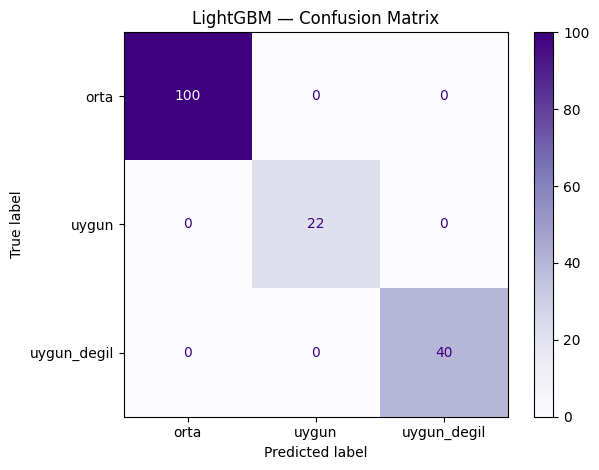

In [48]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

preprocessor_lgbm = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

lgbm_pipeline = ImbPipeline([
    ('preprocessor', preprocessor_lgbm),
    ('smote', SMOTE(random_state=42)),
    ('model', LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        class_weight='balanced',
        random_state=42,
        verbose=-1,
        n_jobs=1,
    ))
])

lgbm_pipeline.fit(X_train, y_train)
y_pred_lgbm = lgbm_pipeline.predict(X_test)

print("=== LightGBM Sonuçları ===\n")
print(classification_report(y_test, y_pred_lgbm))

cv_scores_lgbm = cross_val_score(lgbm_pipeline, X, y, cv=5, scoring='f1_weighted')
print(f"5-Fold CV F1 (weighted): {cv_scores_lgbm.mean():.3f} ± {cv_scores_lgbm.std():.3f}")

cm_lgbm = confusion_matrix(y_test, y_pred_lgbm, labels=lgbm_pipeline.classes_)
disp_lgbm = ConfusionMatrixDisplay(confusion_matrix=cm_lgbm, display_labels=lgbm_pipeline.classes_)
disp_lgbm.plot(cmap='Purples')
plt.title("LightGBM — Confusion Matrix")
plt.tight_layout()
plt.show()

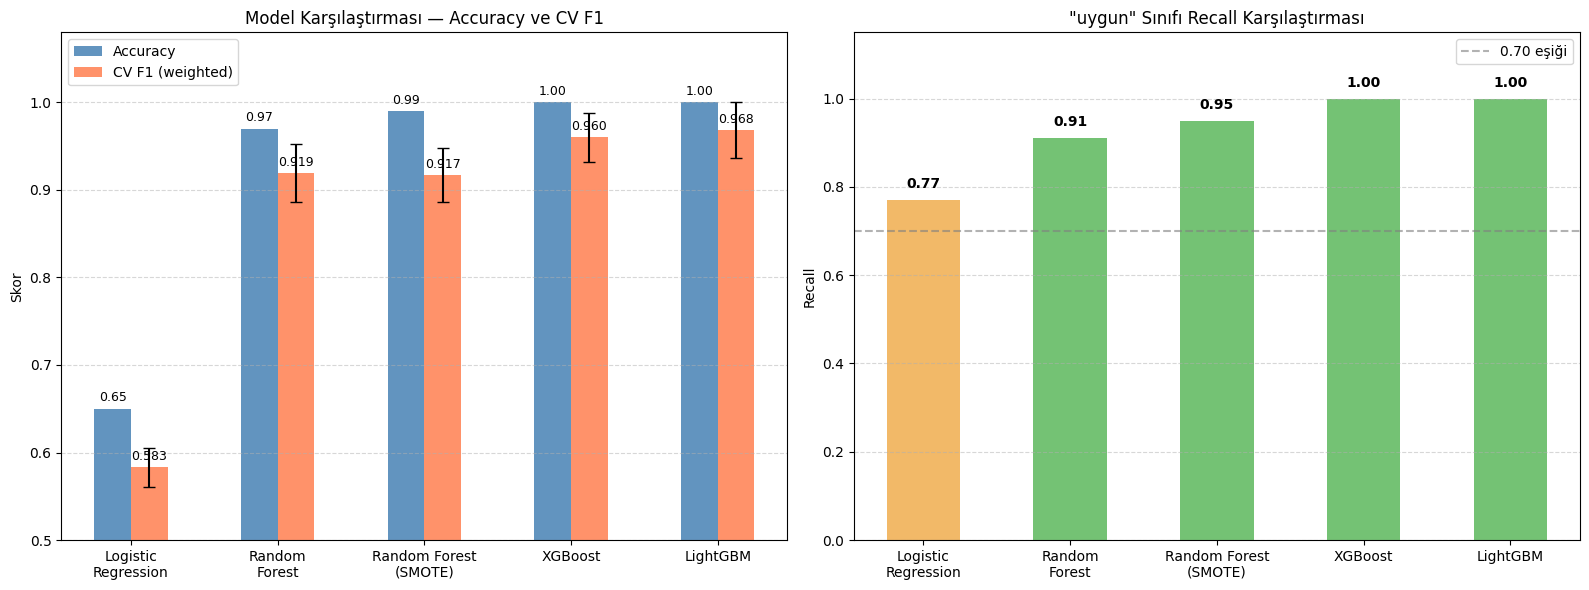

✅ Grafik kaydedildi: model_karsilastirma.png


In [50]:
# Model Karşılaştırma Grafikleri (accuracy ve recall)
#ilk grafikteki hata çubukları (error bars) — CV F1 skorunun ± standart sapmasını gösteriyor

import matplotlib.pyplot as plt
import numpy as np

model_names = [
    'Logistic\nRegression',
    'Random\nForest',
    'Random Forest\n(SMOTE)',
    'XGBoost',
    'LightGBM'
]

accuracy     = [0.65, 0.97, 0.99, 1.00, 1.00]
cv_f1_mean   = [0.583, 0.919, 0.917, 0.960, 0.968]
cv_f1_std    = [0.022, 0.033, 0.031, 0.028, 0.032]
uygun_recall = [0.77, 0.91, 0.95, 1.00, 1.00]

x = np.arange(len(model_names))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sol grafik: Accuracy ve CV F1
bars1 = axes[0].bar(x - width/2, accuracy, width, label='Accuracy', color='steelblue', alpha=0.85)
bars2 = axes[0].bar(x + width/2, cv_f1_mean, width, label='CV F1 (weighted)', color='coral', alpha=0.85)

axes[0].errorbar(x + width/2, cv_f1_mean, yerr=cv_f1_std,
                 fmt='none', color='black', capsize=4, linewidth=1.5)

axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, fontsize=10)
axes[0].set_ylim(0.50, 1.08)
axes[0].set_ylabel('Skor')
axes[0].set_title('Model Karşılaştırması — Accuracy ve CV F1')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

# Sağ grafik: uygun sınıfı recall
colors = ['#d9534f' if r < 0.5 else '#f0ad4e' if r < 0.8 else '#5cb85c' for r in uygun_recall]
bars3 = axes[1].bar(x, uygun_recall, width=0.5, color=colors, alpha=0.85)

axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, fontsize=10)
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('Recall')
axes[1].set_title('"uygun" Sınıfı Recall Karşılaştırması')
axes[1].axhline(y=0.7, color='gray', linestyle='--', alpha=0.6, label='0.70 eşiği')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('model_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik kaydedildi: model_karsilastirma.png")

/Users/zeynepyildirim/Desktop/TezBitirme/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/zeynepyildirim/Desktop/TezBitirme/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== Voting Classifier Sonuçları ===

              precision    recall  f1-score   support

        orta       1.00      0.99      0.99       100
       uygun       0.96      1.00      0.98        22
 uygun_degil       1.00      1.00      1.00        40

    accuracy                           0.99       162
   macro avg       0.99      1.00      0.99       162
weighted avg       0.99      0.99      0.99       162



/Users/zeynepyildirim/Desktop/TezBitirme/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/zeynepyildirim/Desktop/TezBitirme/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/zeynepyildirim/Desktop/TezBitirme/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/zeynepyildirim/Desktop/TezBitirme/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


5-Fold CV F1 (weighted): 0.961 ± 0.018


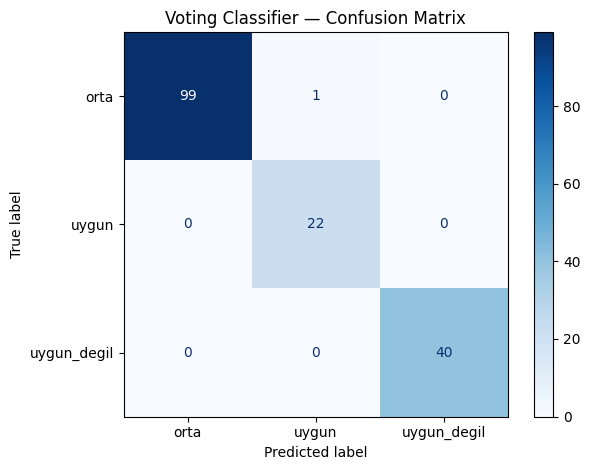

In [51]:
# Voting Classifier (LR + RF + LightGBM birleşimi) Modeli

from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# Her model için ayrı preprocessor — VotingClassifier pipeline içine alınıyor
def make_preprocessor():
    return ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

lr_pipe = Pipeline([
    ('preprocessor', make_preprocessor()),
    ('model', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42))
])

rf_pipe = Pipeline([
    ('preprocessor', make_preprocessor()),
    ('model', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=1))
])

lgbm_pipe = Pipeline([
    ('preprocessor', make_preprocessor()),
    ('model', LGBMClassifier(n_estimators=100, class_weight='balanced', random_state=42, verbose=-1, n_jobs=1))
])

voting_model = VotingClassifier(
    estimators=[
        ('lr',   lr_pipe),
        ('rf',   rf_pipe),
        ('lgbm', lgbm_pipe)
    ],
    voting='soft'
)

voting_model.fit(X_train, y_train)
y_pred_voting = voting_model.predict(X_test)

print("=== Voting Classifier Sonuçları ===\n")
print(classification_report(y_test, y_pred_voting))

cv_scores_voting = cross_val_score(voting_model, X, y, cv=5, scoring='f1_weighted', n_jobs=1)
print(f"5-Fold CV F1 (weighted): {cv_scores_voting.mean():.3f} ± {cv_scores_voting.std():.3f}")

cm_v = confusion_matrix(y_test, y_pred_voting, labels=voting_model.classes_)
disp_v = ConfusionMatrixDisplay(confusion_matrix=cm_v, display_labels=voting_model.classes_)
disp_v.plot(cmap='Blues')
plt.title("Voting Classifier — Confusion Matrix")
plt.tight_layout()
plt.show()

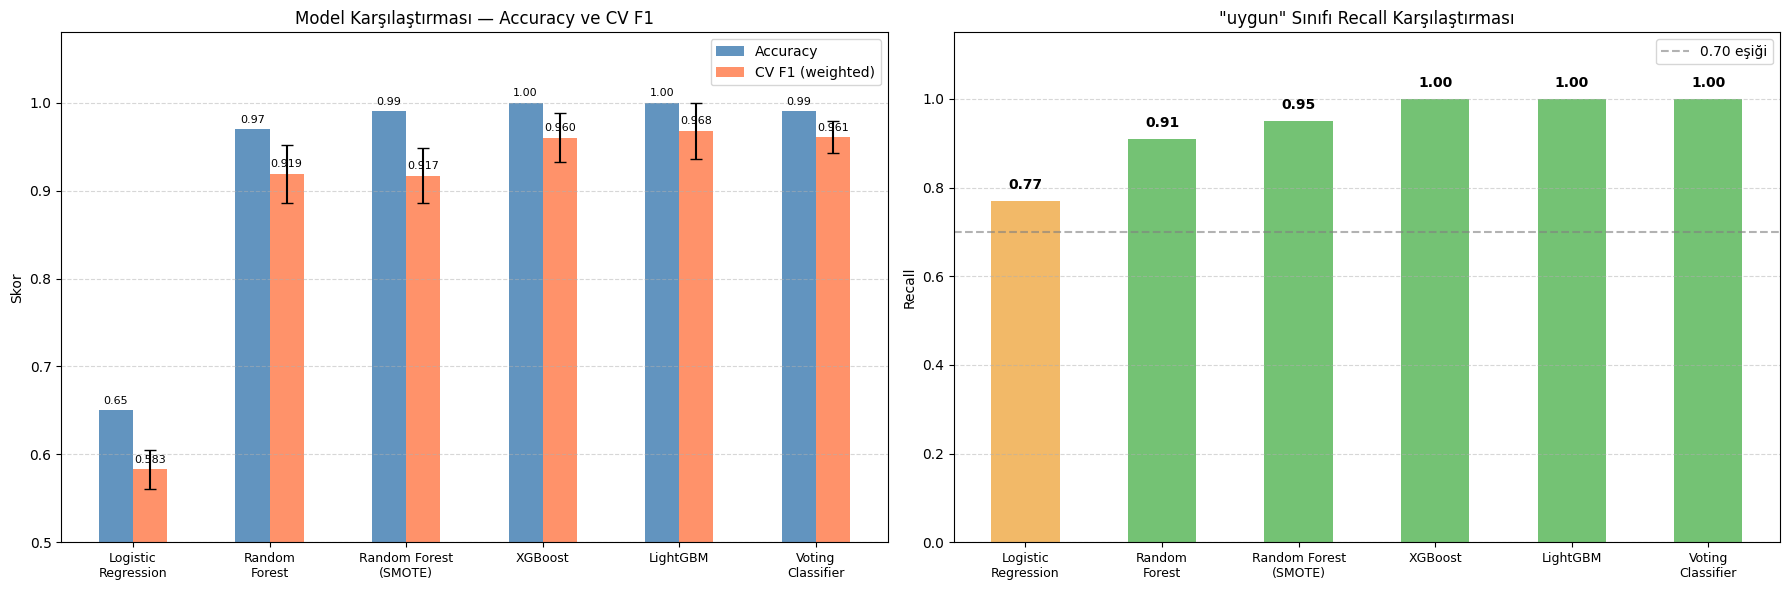

✅ Grafik kaydedildi: model_karsilastirma_final.png


In [52]:
# Güncel Model Karşılaştırma Grafiği (Voting dahil)

import matplotlib.pyplot as plt
import numpy as np

model_names = [
    'Logistic\nRegression',
    'Random\nForest',
    'Random Forest\n(SMOTE)',
    'XGBoost',
    'LightGBM',
    'Voting\nClassifier'
]

accuracy     = [0.65, 0.97, 0.99, 1.00, 1.00, 0.99]
cv_f1_mean   = [0.583, 0.919, 0.917, 0.960, 0.968, 0.961]
cv_f1_std    = [0.022, 0.033, 0.031, 0.028, 0.032, 0.018]
uygun_recall = [0.77, 0.91, 0.95, 1.00, 1.00, 1.00]

x = np.arange(len(model_names))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Sol: Accuracy ve CV F1
bars1 = axes[0].bar(x - width/2, accuracy, width, label='Accuracy', color='steelblue', alpha=0.85)
bars2 = axes[0].bar(x + width/2, cv_f1_mean, width, label='CV F1 (weighted)', color='coral', alpha=0.85)
axes[0].errorbar(x + width/2, cv_f1_mean, yerr=cv_f1_std,
                 fmt='none', color='black', capsize=4, linewidth=1.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, fontsize=9)
axes[0].set_ylim(0.50, 1.08)
axes[0].set_ylabel('Skor')
axes[0].set_title('Model Karşılaştırması — Accuracy ve CV F1')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# Sağ: uygun recall
colors = ['#d9534f' if r < 0.5 else '#f0ad4e' if r < 0.8 else '#5cb85c' for r in uygun_recall]
bars3 = axes[1].bar(x, uygun_recall, width=0.5, color=colors, alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, fontsize=9)
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('Recall')
axes[1].set_title('"uygun" Sınıfı Recall Karşılaştırması')
axes[1].axhline(y=0.7, color='gray', linestyle='--', alpha=0.6, label='0.70 eşiği')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('model_karsilastirma_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik kaydedildi: model_karsilastirma_final.png")

In [53]:
# XGBoost Overfitting Testi
#overfitting yok görünüyor ama aslında model bizim oluşturduğumuz uygunluk skorunu oluşturma formülünü öğrendi
#şuanda teknik olarak en iyi model xgboost ama yine de dikkatli olunmalı, model skor formülünü öğrendiği için en iyi görünüyo olabilir
#gerçek verilerle overfitting ortaya çıkabililir
#bu yüzden en iyi model olarak hem LightGBM hem de Xgboost'u kaydediyorum!!
# "Etiketler kural bazlı üretildiğinden XGBoost mükemmel sonuç vermiştir. Gerçek kampanya verileriyle yeniden eğitildiğinde performans farklılaşabilir."

# Eğitim seti üzerinde tahmin
# Eğitim seti üzerinde tahmin
y_pred_train_xgb = xgb_pipeline.predict(X_train)
y_pred_train_xgb = le.inverse_transform(y_pred_train_xgb)
y_train_original = le.inverse_transform(y_train_enc)

print("=== XGBoost — Eğitim Seti Performansı ===")
print(classification_report(y_train_original, y_pred_train_xgb))

print("=== XGBoost — Test Seti Performansı ===")
print(classification_report(y_test, y_pred_xgb))

from sklearn.metrics import accuracy_score
train_acc = accuracy_score(y_train_original, y_pred_train_xgb)
test_acc  = accuracy_score(y_test, y_pred_xgb)

print(f"Eğitim accuracy: {train_acc:.3f}")
print(f"Test accuracy:   {test_acc:.3f}")
print(f"Fark:            {train_acc - test_acc:.3f}")

if train_acc - test_acc > 0.05:
    print("\n⚠️  Overfitting var — eğitim ve test arasındaki fark büyük")
else:
    print("\n✅ Overfitting yok — eğitim ve test sonuçları tutarlı")

=== XGBoost — Eğitim Seti Performansı ===
              precision    recall  f1-score   support

        orta       1.00      1.00      1.00       403
       uygun       1.00      1.00      1.00        86
 uygun_degil       1.00      1.00      1.00       159

    accuracy                           1.00       648
   macro avg       1.00      1.00      1.00       648
weighted avg       1.00      1.00      1.00       648

=== XGBoost — Test Seti Performansı ===
              precision    recall  f1-score   support

        orta       1.00      1.00      1.00       100
       uygun       1.00      1.00      1.00        22
 uygun_degil       1.00      1.00      1.00        40

    accuracy                           1.00       162
   macro avg       1.00      1.00      1.00       162
weighted avg       1.00      1.00      1.00       162

Eğitim accuracy: 1.000
Test accuracy:   1.000
Fark:            0.000

✅ Overfitting yok — eğitim ve test sonuçları tutarlı


Outlier temizleme sonrası: 133 influencer (öncesi: 135)
engagement_rate max: 48.47

Log transform sonrası engagement_rate istatistikleri:
count    133.000
mean       1.123
std        0.737
min        0.000
25%        0.675
50%        0.962
75%        1.395
max        3.901
Name: engagement_rate_log, dtype: float64
✅ Regresyon veri seti hazır
Eğitim: 106, Test: 27

Hedef değişken (engagement_rate) istatistikleri:
count    133.00
mean       1.12
std        0.74
min        0.00
25%        0.67
50%        0.96
75%        1.40
max        3.90
Name: engagement_rate_log, dtype: float64

=== Linear Regression ===
MAE : 0.549
RMSE: 0.885
R²  : -1.005
5-Fold CV R²: -0.126 ± 0.124

=== Random Forest Regressor ===
MAE : 0.247
RMSE: 0.308
R²  : 0.757
5-Fold CV R²: 0.581 ± 0.148

=== XGBoost Regressor ===
MAE : 0.243
RMSE: 0.311
R²  : 0.752
5-Fold CV R²: 0.617 ± 0.170


=== REGRESYON MODELLERİ KARŞILAŞTIRMA ===
Model                          MAE     RMSE       R²      CV R²
-------------------------

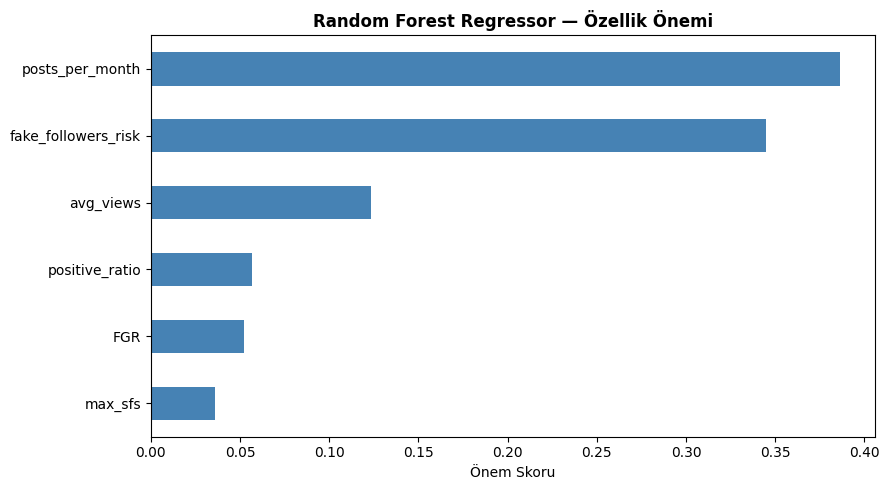

✅ regresyon_ozellik_onemi.png kaydedildi


In [55]:
# ============================================================
# REGRESYON MODELLERİ
# Amaç: Fenomenin etkileşim oranını (engagement_rate) tahmin etmek
# "Bu fenomen kampanyada kaç etkileşim alır?" sorusunu yanıtlar
# Modeller: Linear Regression, RF Regressor, XGBoost Regressor
# Metrikler: MAE, RMSE, R²
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import numpy as np

# fake_followers_risk yoksa üret
if 'fake_followers_risk' not in influencer_summary.columns:
    def _detect_fake_engagement(er):
        if 1 <= er <= 5:   return 0
        if er < 0.5:       return 85
        if er > 10:        return 60
        if er < 1:         return 30
        return 0

    def _detect_fake_growth(fgr, post_count):
        if post_count > 30 and fgr < 5:   return 0
        if post_count < 15 and fgr > 30:  return 70
        if 5 <= fgr <= 15:                return 0
        if fgr > 30:                      return 50
        if fgr < 1 and post_count > 50:   return 20
        return 0

    def _detect_fake_reach(avg_reach, avg_views):
        if avg_views == 0 or avg_reach == 0: return 0
        ratio = avg_reach / avg_views
        if 0.10 <= ratio <= 0.50: return 0
        if ratio < 0.05:          return 75
        if ratio > 0.50:          return 40
        return 20

    influencer_summary['fake_engagement_score'] = influencer_summary['engagement_rate'].apply(_detect_fake_engagement)
    influencer_summary['fake_growth_score'] = influencer_summary.apply(
        lambda r: _detect_fake_growth(r['FGR'], r['post_count']), axis=1)
    influencer_summary['fake_reach_score'] = influencer_summary.apply(
        lambda r: _detect_fake_reach(r['avg_post_reach'], r['avg_views']), axis=1)
    influencer_summary['fake_followers_risk'] = (
        influencer_summary['fake_engagement_score'] * 0.5 +
        influencer_summary['fake_growth_score']     * 0.3 +
        influencer_summary['fake_reach_score']      * 0.2
    ).round(1)

    def _categorize_risk(score):
        if score >= 70:   return '⚠️ ÇOK YÜKSEK'
        elif score >= 50: return '🟡 ORTA'
        elif score >= 30: return '🟢 DÜŞÜK'
        return '✅ TEMİZ'
    influencer_summary['risk_category'] = influencer_summary['fake_followers_risk'].apply(_categorize_risk)

# Outlier temizleme — engagement_rate'in %99 persentilinin üstündekileri kaldır
er_p99 = influencer_summary['engagement_rate'].quantile(0.99)
reg_df = influencer_summary[influencer_summary['engagement_rate'] <= er_p99].copy()

print(f"Outlier temizleme sonrası: {len(reg_df)} influencer (öncesi: {len(influencer_summary)})")
print(f"engagement_rate max: {reg_df['engagement_rate'].max():.2f}")

# Log transform — sağa çarpık dağılımı normalize et
import numpy as np
reg_df['engagement_rate_log'] = np.log1p(reg_df['engagement_rate'])

reg_df['max_sfs'] = reg_df[sfs_cols].max(axis=1)

X_reg = reg_df[reg_features].fillna(0)
y_reg = reg_df['engagement_rate_log']  # log transform edilmiş hedef

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"\nLog transform sonrası engagement_rate istatistikleri:")
print(y_reg.describe().round(3))

print(f"✅ Regresyon veri seti hazır")
print(f"Eğitim: {len(X_reg_train)}, Test: {len(X_reg_test)}")
print(f"\nHedef değişken (engagement_rate) istatistikleri:")
print(y_reg.describe().round(2))

# 2. Modelleri tanımla
reg_models = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Random Forest Regressor': RandomForestRegressor(
        n_estimators=100, random_state=42
    ),
    'XGBoost Regressor': XGBRegressor(
        n_estimators=100, learning_rate=0.1,
        max_depth=6, eval_metric='rmse', random_state=42
    )
}

# 3. Eğit ve değerlendir
reg_results = {}

for name, model in reg_models.items():
    model.fit(X_reg_train, y_reg_train)
    y_pred = model.predict(X_reg_test)

    mae  = mean_absolute_error(y_reg_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred))
    r2   = r2_score(y_reg_test, y_pred)
    cv_r2 = cross_val_score(model, X_reg, y_reg, cv=5, scoring='r2')

    reg_results[name] = {
        'MAE': round(mae, 3), 'RMSE': round(rmse, 3),
        'R²': round(r2, 3), 'CV R² Ort': round(cv_r2.mean(), 3),
        'CV R² Std': round(cv_r2.std(), 3)
    }

    print(f"\n=== {name} ===")
    print(f"MAE : {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²  : {r2:.3f}")
    print(f"5-Fold CV R²: {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

# 4. Karşılaştırma tablosu
print("\n\n=== REGRESYON MODELLERİ KARŞILAŞTIRMA ===")
print(f"{'Model':<25} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'CV R²':>10}")
print("-" * 65)
for name, res in reg_results.items():
    print(f"{name:<25} {res['MAE']:>8.3f} {res['RMSE']:>8.3f} "
          f"{res['R²']:>8.3f} {res['CV R² Ort']:>8.3f} ± {res['CV R² Std']:.3f}")

# 5. RF özellik önemi
rf_reg = reg_models['Random Forest Regressor']
feat_imp_reg = pd.Series(
    rf_reg.feature_importances_,
    index=reg_features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
feat_imp_reg.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Random Forest Regressor — Özellik Önemi', fontsize=12, fontweight='bold')
ax.set_xlabel('Önem Skoru')
plt.tight_layout()
plt.savefig('regresyon_ozellik_onemi.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ regresyon_ozellik_onemi.png kaydedildi")

In [56]:
# ============================================================
# CHECKPOINT — influencer_summary'yi diske kaydet
# Kernel crash olursa baştan çalıştırmak zorunda kalmamak için
# ============================================================

import pickle

with open('influencer_summary_checkpoint.pkl', 'wb') as f:
    pickle.dump(influencer_summary, f)

print("✅ Checkpoint kaydedildi: influencer_summary_checkpoint.pkl")
print(f"Satır: {influencer_summary.shape[0]}, Sütun: {influencer_summary.shape[1]}")

✅ Checkpoint kaydedildi: influencer_summary_checkpoint.pkl
Satır: 135, Sütun: 51


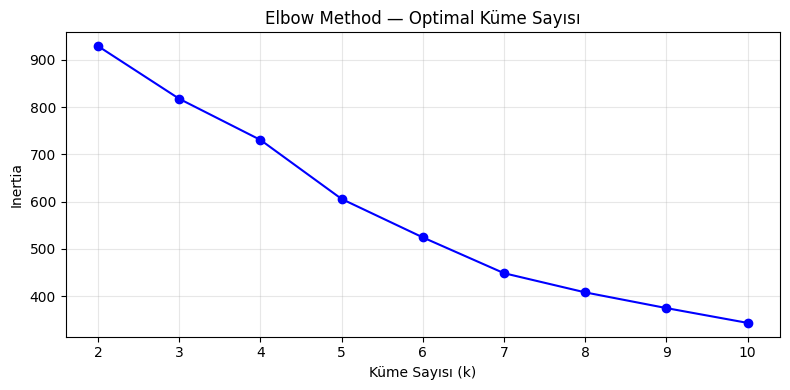

Outlier sayısı: 11
Cluster dağılımı:
similarity_cluster
0    42
1    35
2    39
3    19
Name: count, dtype: int64


In [59]:
# ============================================================
# ADIM 1A — K-Means ile Benzer Fenomen Tespiti
# Elbow method ile optimal küme sayısı belirlenir
# Aynı cluster = benzer profil
# ============================================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Madde 12: SFS skorları da eklendi — içerik benzerliği + performans
sfs_cols_km = [
    'sim_spor_kampanyasi', 'sim_moda_kampanyasi', 'sim_teknoloji_kampanyasi',
    'sim_yemek_kampanyasi', 'sim_annebebek_kampanyasi', 'sim_oyun_kampanyasi'
]

km_features = ['engagement_rate', 'FGR', 'posts_per_month', 'avg_views'] + sfs_cols_km

features_km = influencer_summary[km_features].fillna(0)
scaler_km = StandardScaler()
features_scaled_km = scaler_km.fit_transform(features_km)

# Elbow method
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features_scaled_km)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Küme Sayısı (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal Küme Sayısı')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

# K=6 ile modeli eğit
def add_similarity_clustering(df):
    df = df.copy()
    features = df[km_features].fillna(0)
    
    # Outlier'ları geçici olarak çıkar, sonra en yakın cluster'a ata
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    
    # IQR bazlı outlier tespiti
    from scipy.stats import zscore
    z_scores = np.abs(zscore(features_scaled))
    outlier_mask = (z_scores > 3).any(axis=1)
    
    print(f"Outlier sayısı: {outlier_mask.sum()}")
    
    # Normal verilerle cluster eğit
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    normal_labels = kmeans.fit_predict(features_scaled[~outlier_mask])
    
    # Outlier'ları en yakın cluster'a ata
    all_labels = np.zeros(len(df), dtype=int)
    all_labels[~outlier_mask] = normal_labels
    all_labels[outlier_mask] = kmeans.predict(features_scaled[outlier_mask])
    
    df['similarity_cluster'] = all_labels
    return df

influencer_summary = add_similarity_clustering(influencer_summary)
print(f"Cluster dağılımı:\n{influencer_summary['similarity_cluster'].value_counts().sort_index()}")

In [60]:
# ============================================================
# ADIM 1B — Demografik / Cinsiyet Tahmini
# Kategori bazlı olasılık + hashtag anahtar kelime analizi
# estimated_gender ve gender_confidence sütunları üretilir
# ============================================================

def add_demographic_analysis(df):
    df = df.copy()
    category_demographics = {
        'moda':        {'kadın': 0.75, 'erkek': 0.20, 'belirsiz': 0.05},
        'anne-bebek':  {'kadın': 0.90, 'erkek': 0.05, 'belirsiz': 0.05},
        'saglik':      {'kadın': 0.65, 'erkek': 0.30, 'belirsiz': 0.05},
        'yemek':       {'kadın': 0.60, 'erkek': 0.35, 'belirsiz': 0.05},
        'egitim':      {'kadın': 0.55, 'erkek': 0.40, 'belirsiz': 0.05},
        'spor':        {'kadın': 0.45, 'erkek': 0.50, 'belirsiz': 0.05},
        'oyun':        {'kadın': 0.30, 'erkek': 0.65, 'belirsiz': 0.05},
        'teknoloji':   {'kadın': 0.35, 'erkek': 0.60, 'belirsiz': 0.05},
        'lifestyle':   {'kadın': 0.60, 'erkek': 0.35, 'belirsiz': 0.05},
        'seyahat':     {'kadın': 0.55, 'erkek': 0.40, 'belirsiz': 0.05},
        'evcilhayvan': {'kadın': 0.55, 'erkek': 0.35, 'belirsiz': 0.10},
        'diğer':       {'kadın': 0.50, 'erkek': 0.45, 'belirsiz': 0.05},
    }
    gender_keywords = {
        'kadın': ['kız', 'kadın', 'girl', 'woman', 'bayan', 'mom', 'anne', 'makeup', 'makyaj'],
        'erkek': ['erkek', 'boy', 'man', 'abi', 'baba', 'daddy', 'gym', 'gaming'],
    }
    def estimate_demographic(row):
        category = str(row['category']).lower() if pd.notna(row['category']) else 'diğer'
        tags = str(row['clean_tags_all']).lower()
        for gender, keywords in gender_keywords.items():
            if any(kw in tags for kw in keywords):
                return gender, 0.8
        if category in category_demographics:
            probs = category_demographics[category]
            estimated = max(probs, key=probs.get)
            return estimated, probs[estimated]
        return 'belirsiz', 0.3

    df[['estimated_gender', 'gender_confidence']] = df.apply(
        lambda row: pd.Series(estimate_demographic(row)), axis=1
    )
    return df

influencer_summary = add_demographic_analysis(influencer_summary)
print("✅ Demografik analiz tamamlandı")
print(f"Cinsiyet dağılımı:\n{influencer_summary['estimated_gender'].value_counts()}")
print(f"Ortalama güven skoru: {influencer_summary['gender_confidence'].mean():.2%}")

✅ Demografik analiz tamamlandı
Cinsiyet dağılımı:
estimated_gender
kadın    100
erkek     35
Name: count, dtype: int64
Ortalama güven skoru: 70.30%


In [61]:
# ============================================================
# ADIM 1C — Fake Takipçi Risk Skoru
# 3 metrik: engagement anomalisi + büyüme tutarsızlığı + reach/follower oranı
# fake_followers_risk (0-100) ve risk_category sütunları üretilir
# Yüksek skor = sahte takipçi riski yüksek
# ============================================================

def add_fake_followers_detection(df):
    df = df.copy()

    def detect_fake_engagement(er):
        if 1 <= er <= 5:  return 0
        if er < 0.5:      return 85
        if er > 10:       return 60
        if er < 1:        return 30
        return 0

    def detect_fake_growth(fgr, post_count):
        if post_count > 30 and fgr < 5:  return 0
        if post_count < 15 and fgr > 30: return 70
        if 5 <= fgr <= 15:               return 0
        if fgr > 30:                     return 50
        if fgr < 1 and post_count > 50:  return 20
        return 0

    def detect_fake_reach(avg_reach, avg_views):
        # avg_views kullanıyoruz — followers verisi yok
        if avg_views == 0 or avg_reach == 0: return 0
        ratio = avg_reach / avg_views
        if 0.80 <= ratio <= 1.20: return 0   # reach ≈ views normal
        if ratio < 0.30:          return 75  # çok düşük reach
        if ratio > 2.0:           return 40  # şüpheli yüksek reach
        return 20

    def categorize_risk(score):
        if score >= 70:   return '⚠️ ÇOK YÜKSEK'
        elif score >= 50: return '🟡 ORTA'
        elif score >= 30: return '🟢 DÜŞÜK'
        else:             return '✅ TEMİZ'

    df['fake_engagement_score'] = df['engagement_rate'].apply(detect_fake_engagement)
    df['fake_growth_score'] = df.apply(
        lambda r: detect_fake_growth(r['FGR'], r['post_count']), axis=1)
    df['fake_reach_score'] = df.apply(
        lambda r: detect_fake_reach(r['avg_post_reach'], r['avg_views']), axis=1)
    df['fake_followers_risk'] = (
        df['fake_engagement_score'] * 0.5 +
        df['fake_growth_score']     * 0.3 +
        df['fake_reach_score']      * 0.2
    ).round(1)
    df['risk_category'] = df['fake_followers_risk'].apply(categorize_risk)
    return df

influencer_summary = add_fake_followers_detection(influencer_summary)
print("✅ Fake takipçi tespiti tamamlandı")
print(f"Risk dağılımı:\n{influencer_summary['risk_category'].value_counts()}")
print(f"\nEn riskli 5 fenomen:")
print(influencer_summary.sort_values('fake_followers_risk', ascending=False)
      [['influencer_name', 'category', 'fake_followers_risk', 'risk_category']].head())

✅ Fake takipçi tespiti tamamlandı
Risk dağılımı:
risk_category
✅ TEMİZ    107
🟢 DÜŞÜK     25
🟡 ORTA       3
Name: count, dtype: int64

En riskli 5 fenomen:
        influencer_name   category  fake_followers_risk risk_category
121             zey_zor      diğer                 57.5        🟡 ORTA
82            modamerve  teknoloji                 57.5        🟡 ORTA
13          bizim.zeyno      yemek                 57.5        🟡 ORTA
127  zeynepceltek_adana     saglik                 42.5       🟢 DÜŞÜK
18      butikmerveaksoy      diğer                 42.5       🟢 DÜŞÜK


In [62]:
# XGBoost Modelini Kaydetme

import joblib

# xgb_pipeline olarak kaydet
joblib.dump(xgb_pipeline, 'best_model_xgb.pkl')
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(num_cols + cat_cols, 'feature_columns.pkl')

print("✅ Kaydedilen dosyalar:")
print("   - best_model_xgb.pkl  → XGBoost pipeline (preprocessor + SMOTE + model)")
print("   - label_encoder.pkl   → Etiket encoder")
print("   - feature_columns.pkl → Model giriş sütunları")

# Final özet — güncel değerler
print("\n MODEL EĞİTİMİ ÖZET ")
print(f"{'Model':<30} {'Accuracy':>10} {'CV F1':>10} {'±std':>8} {'Uygun Recall':>14}")
print("-" * 75)
results = [
    ('Logistic Regression',            0.65, 0.583, 0.022, 0.77),
    ('Random Forest',                  0.97, 0.919, 0.033, 0.91),
    ('Random Forest (SMOTE)',          0.99, 0.917, 0.031, 0.95),
    ('XGBoost ⭐ (seçilen)',            1.00, 0.960, 0.028, 1.00),
    ('LightGBM',                       1.00, 0.968, 0.032, 1.00),
    ('Voting Classifier',              0.99, 0.961, 0.018, 1.00),
]
for name, acc, f1, std, rec in results:
    print(f"{name:<30} {acc:>10.2f} {f1:>10.3f} {std:>8.3f} {rec:>14.2f}")

✅ Kaydedilen dosyalar:
   - best_model_xgb.pkl  → XGBoost pipeline (preprocessor + SMOTE + model)
   - label_encoder.pkl   → Etiket encoder
   - feature_columns.pkl → Model giriş sütunları

 MODEL EĞİTİMİ ÖZET 
Model                            Accuracy      CV F1     ±std   Uygun Recall
---------------------------------------------------------------------------
Logistic Regression                  0.65      0.583    0.022           0.77
Random Forest                        0.97      0.919    0.033           0.91
Random Forest (SMOTE)                0.99      0.917    0.031           0.95
XGBoost ⭐ (seçilen)                  1.00      0.960    0.028           1.00
LightGBM                             1.00      0.968    0.032           1.00
Voting Classifier                    0.99      0.961    0.018           1.00


In [63]:
# ============================================================
# CHECKPOINT GÜNCELLEME
# Adım 1A, 1B, 1C tamamlandı. Yeni sütunlar eklendi:
# similarity_cluster, estimated_gender, gender_confidence,
# fake_followers_risk, risk_category
# ============================================================

import pickle
with open('influencer_summary_checkpoint.pkl', 'wb') as f:
    pickle.dump(influencer_summary, f)

print("✅ Checkpoint güncellendi")
print(f"Satır: {influencer_summary.shape[0]}, Sütun: {influencer_summary.shape[1]}")
print(f"Yeni sütunlar: {influencer_summary.columns.tolist()[-5:]}")

✅ Checkpoint güncellendi
Satır: 135, Sütun: 54
Yeni sütunlar: ['risk_category', 'max_sfs', 'similarity_cluster', 'estimated_gender', 'gender_confidence']


In [64]:
# ============================================================
# ADIM 2 — Brand Alignment Score (BAS) Hesaplama
# Her fenomen için kampanyadan bağımsız genel bir 0-100 uyum skoru
# Bileşenler:
#   %35 SFS  → içerik-kampanya semantik benzerliği (en yüksek kampanya skoru)
#   %30 NFS  → sayısal performans skoru
#   %25 Sentiment → pozitif içerik oranı
#   %10 Temizlik bonusu → fake risk ne kadar düşükse o kadar yüksek
# ============================================================

def calculate_bas(row):
    sfs_cols = [
        'sim_spor_kampanyasi', 'sim_moda_kampanyasi',
        'sim_teknoloji_kampanyasi', 'sim_yemek_kampanyasi',
        'sim_annebebek_kampanyasi', 'sim_oyun_kampanyasi'
    ]
    sfs_100     = row[sfs_cols].max() * 100
    nfs         = row['NFS']
    # Madde 4 düzeltmesi: signed_sentiment 0-1 arası normalize et
    signed      = row['avg_signed_sentiment']           # -1 ile +1 arası
    sentiment   = ((signed + 1) / 2) * 100              # 0-100'e çevir
    clean_bonus = 100 - row['fake_followers_risk']

    bas = (
        sfs_100     * 0.35 +
        nfs         * 0.30 +
        sentiment   * 0.25 +
        clean_bonus * 0.10
    )
    return round(float(bas), 2)

influencer_summary['BAS'] = influencer_summary.apply(calculate_bas, axis=1)
influencer_summary['BAS'] = influencer_summary['BAS'].clip(0, 100)

print("✅ BAS hesaplandı\n")
print("En yüksek BAS skoruna sahip 10 fenomen:")
print(influencer_summary[['influencer_name', 'category', 'NFS', 'BAS',
                           'fake_followers_risk', 'risk_category', 'estimated_gender']]
      .sort_values('BAS', ascending=False).head(10).to_string(index=False))

✅ BAS hesaplandı

En yüksek BAS skoruna sahip 10 fenomen:
      influencer_name   category   NFS   BAS  fake_followers_risk risk_category estimated_gender
   murattatikofficial      diğer 91.12 67.74                 30.0       🟢 DÜŞÜK            erkek
          caglaralkac      diğer 87.85 60.26                 30.0       🟢 DÜŞÜK            kadın
     zeyneptugcebayat anne-bebek  0.60 58.66                  0.0       ✅ TEMİZ            kadın
  dilarakocakiyiyasam       spor  1.65 54.30                  0.0       ✅ TEMİZ            kadın
ebrukaradumanofficial       spor  0.85 54.23                  0.0       ✅ TEMİZ            kadın
           orkunolgar anne-bebek  3.16 52.78                  0.0       ✅ TEMİZ            kadın
         duyguozaslan       moda  0.81 52.60                  0.0       ✅ TEMİZ            kadın
 prof.dr.ferhatcekmez anne-bebek  1.47 52.37                  0.0       ✅ TEMİZ            kadın
             ebruakel       spor  0.80 51.78                  0.0    

In [65]:
# ============================================================
# ADIM 3 — Kampanya Bazlı Top-5 Öneri Listesi
# Her kampanya için SFS + NFS + Sentiment + Fake risk birleştirilerek
# o kampanyaya özel BAS skoru hesaplanır ve en uygun 5 fenomen seçilir
# Bu liste projenin asıl çıktısı — markaya önerilecek fenomenler
# ============================================================

def get_top5_for_campaign(campaign_name, sim_col, df, top_n=5):
    df = df.copy()

    df['campaign_sfs_100'] = df[sim_col] * 100

    # Madde 4 düzeltmesi: signed_sentiment normalize et
    signed_normalized = ((df['avg_signed_sentiment'] + 1) / 2) * 100

    df['campaign_bas'] = (
        df['campaign_sfs_100']            * 0.35 +
        df['NFS']                         * 0.30 +
        signed_normalized                 * 0.25 +
        (100 - df['fake_followers_risk']) * 0.10
    ).clip(0, 100).round(2)

    top5 = df.sort_values('campaign_bas', ascending=False).head(top_n)

    return top5[[
        'influencer_name', 'category', 'NFS', 'campaign_sfs_100',
        'avg_signed_sentiment', 'fake_followers_risk', 'risk_category',
        'estimated_gender', 'similarity_cluster', 'campaign_bas'
    ]]

campaign_columns = {
    'spor_kampanyasi':      'sim_spor_kampanyasi',
    'moda_kampanyasi':      'sim_moda_kampanyasi',
    'teknoloji_kampanyasi': 'sim_teknoloji_kampanyasi',
    'yemek_kampanyasi':     'sim_yemek_kampanyasi',
    'annebebek_kampanyasi': 'sim_annebebek_kampanyasi',
    'oyun_kampanyasi':      'sim_oyun_kampanyasi'
}

all_top5_results = {}

for campaign_name, sim_col in campaign_columns.items():
    top5 = get_top5_for_campaign(campaign_name, sim_col, influencer_summary)
    all_top5_results[campaign_name] = top5

    print(f"\n{'='*65}")
    print(f"🏆 {campaign_name.upper()} — TOP 5 FENOMEN")
    print(f"{'='*65}")
    print(top5[['influencer_name', 'category', 'campaign_sfs_100',
                'NFS', 'estimated_gender', 'risk_category', 'campaign_bas']]
          .to_string(index=False))

print("\n✅ Tüm kampanyalar için Top-5 listesi oluşturuldu!")


🏆 SPOR_KAMPANYASI — TOP 5 FENOMEN
      influencer_name category  campaign_sfs_100   NFS estimated_gender risk_category  campaign_bas
   murattatikofficial    diğer          5.738021 91.12            erkek       🟢 DÜŞÜK         60.50
          caglaralkac    diğer          6.328117 87.85            kadın       🟢 DÜŞÜK         59.39
  dilarakocakiyiyasam     spor         60.000523  1.65            kadın       ✅ TEMİZ         54.30
ebrukaradumanofficial     spor         54.326828  0.85            kadın       ✅ TEMİZ         54.23
             ebruakel     spor         49.914505  0.80            erkek       ✅ TEMİZ         51.78

🏆 MODA_KAMPANYASI — TOP 5 FENOMEN
   influencer_name category  campaign_sfs_100   NFS estimated_gender risk_category  campaign_bas
murattatikofficial    diğer         12.156001 91.12            erkek       🟢 DÜŞÜK         62.74
       caglaralkac    diğer          6.182309 87.85            kadın       🟢 DÜŞÜK         59.34
      duyguozaslan     moda         55.

In [66]:
# ============================================================
# ADIM 4 — Sonuçları Excel'e Kaydet
# 5 sayfa:
#   1. Tüm Fenomenler   → tüm skorlar bir arada
#   2. Top 20 Fenomenler → BAS'a göre en iyi 20
#   3. Risk Analizi      → fake takipçi riski yüksek hesaplar
#   4. Kategori Özeti    → kategori bazında ortalamalar
#   5. Top-5 Öneriler    → her kampanya için Top-5 listesi
# ============================================================

import pandas as pd

excel_file = 'influencer_analysis_results_v2.xlsx'

with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:

    # Sayfa 1: Tüm fenomenler
    influencer_summary[[
        'influencer_name', 'category', 'account_type', 'country',
        'post_count', 'avg_views', 'engagement_rate',
        'NFS', 'BAS', 'avg_signed_sentiment', 'positive_ratio', 'negative_ratio',
        'estimated_gender', 'gender_confidence',
        'similarity_cluster',
        'fake_followers_risk', 'risk_category'
    ]].sort_values('BAS', ascending=False).to_excel(
        writer, sheet_name='Tüm Fenomenler', index=False
    )

    # Sayfa 2: Top 20
    influencer_summary.nlargest(20, 'BAS')[[
        'influencer_name', 'category', 'engagement_rate',
        'NFS', 'BAS', 'estimated_gender', 'risk_category'
    ]].to_excel(writer, sheet_name='Top 20 Fenomenler', index=False)

    # Sayfa 3: Risk analizi
    influencer_summary[
        influencer_summary['risk_category'] != '✅ TEMİZ'
    ][[
        'influencer_name', 'category', 'engagement_rate', 'FGR',
        'fake_followers_risk', 'risk_category'
    ]].sort_values('fake_followers_risk', ascending=False).to_excel(
        writer, sheet_name='Risk Analizi', index=False
    )

    # Sayfa 4: Kategori özeti
    category_summary = influencer_summary.groupby('category').agg(
        fenomen_sayisi  = ('influencer_name', 'count'),
        ort_NFS         = ('NFS', 'mean'),
        ort_BAS         = ('BAS', 'mean'),
        ort_engagement  = ('engagement_rate', 'mean'),
        ort_fake_risk   = ('fake_followers_risk', 'mean')
    ).round(2).reset_index()
    category_summary.to_excel(writer, sheet_name='Kategori Özeti', index=False)

    # Sayfa 5: Her kampanya için Top-5
    top5_rows = []
    for campaign_name, top5_df in all_top5_results.items():
        for rank, (_, row) in enumerate(top5_df.iterrows(), 1):
            top5_rows.append({
                'kampanya':        campaign_name,
                'sıra':            rank,
                'influencer_name': row['influencer_name'],
                'category':        row['category'],
                'campaign_sfs':    round(row['campaign_sfs_100'], 2),
                'NFS':             round(row['NFS'], 2),
                'BAS':             round(row['campaign_bas'], 2),
                'estimated_gender': row['estimated_gender'],
                'risk_category':   row['risk_category']
            })

    pd.DataFrame(top5_rows).to_excel(
        writer, sheet_name='Top-5 Öneriler', index=False
    )

print(f"✅ Excel kaydedildi: {excel_file}")
print("Sayfalar: Tüm Fenomenler, Top 20, Risk Analizi, Kategori Özeti, Top-5 Öneriler")

✅ Excel kaydedildi: influencer_analysis_results_v2.xlsx
Sayfalar: Tüm Fenomenler, Top 20, Risk Analizi, Kategori Özeti, Top-5 Öneriler


In [67]:
# ============================================================
# CHECKPOINT GÜNCELLEME — Adım 1-4 tamamlandı
# BAS, Top-5 ve Excel çıktısı hazır
# ============================================================

import pickle
with open('influencer_summary_checkpoint.pkl', 'wb') as f:
    pickle.dump(influencer_summary, f)

print("✅ Checkpoint güncellendi")
print(f"Satır: {influencer_summary.shape[0]}, Sütun: {influencer_summary.shape[1]}")
print(f"\nMevcut tüm sütunlar:")
print(influencer_summary.columns.tolist())

✅ Checkpoint güncellendi
Satır: 135, Sütun: 55

Mevcut tüm sütunlar:
['influencer_name', 'total_likes', 'total_comments', 'total_shares', 'avg_likes', 'avg_comments', 'avg_views', 'post_count', 'avg_post_reach', 'first_post', 'last_post', 'category', 'country', 'account_type', 'eng_auth', 'engagement_rate', 'FGR', 'day_active', 'posts_per_month', 'latest_followers', 'oldest_followers', 'clean_tags_all', 'engagement_rate_scaled', 'FGR_scaled', 'posts_per_month_scaled', 'nfs_label', 'NFS', 'sim_spor_kampanyasi', 'sim_moda_kampanyasi', 'sim_teknoloji_kampanyasi', 'sim_yemek_kampanyasi', 'sim_annebebek_kampanyasi', 'sim_oyun_kampanyasi', 'positive_ratio_x', 'negative_ratio_x', 'avg_sentiment_score_x', 'avg_signed_sentiment_x', 'positive_ratio_y', 'negative_ratio_y', 'avg_sentiment_score_y', 'avg_signed_sentiment_y', 'positive_ratio', 'negative_ratio', 'avg_sentiment_score', 'avg_signed_sentiment', 'fake_engagement_score', 'fake_growth_score', 'fake_reach_score', 'fake_followers_risk', 'ris

✅ Veri yüklendi: 135 fenomen, 55 sütun


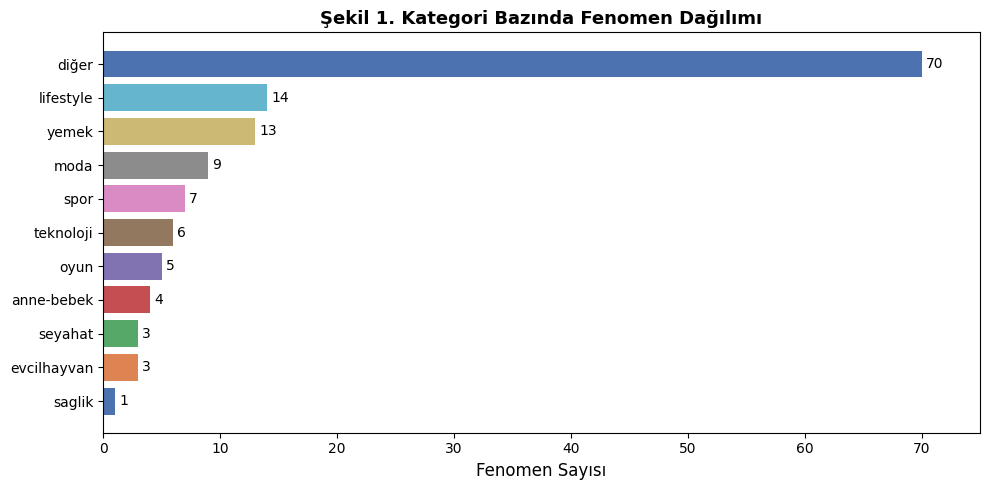

✅ grafik1_kategori_dagilimi.png kaydedildi


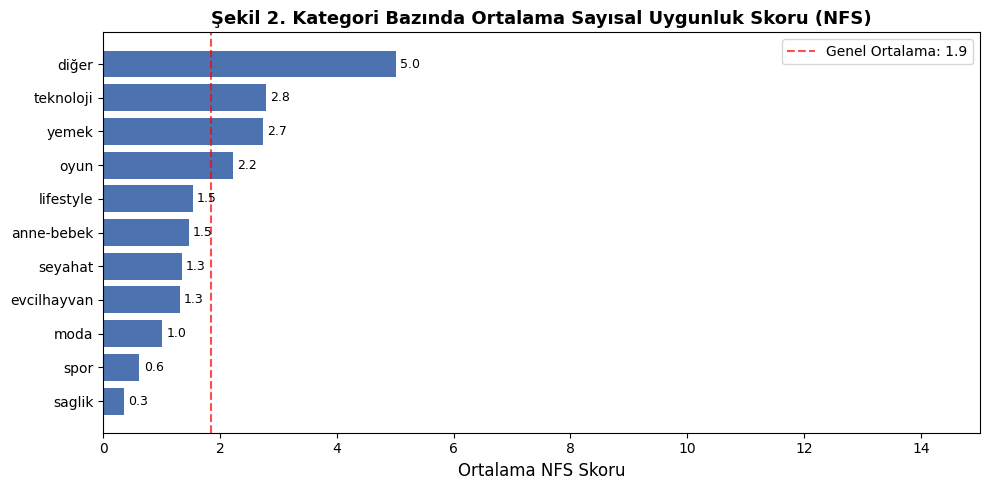

✅ grafik2_nfs_kategori.png kaydedildi


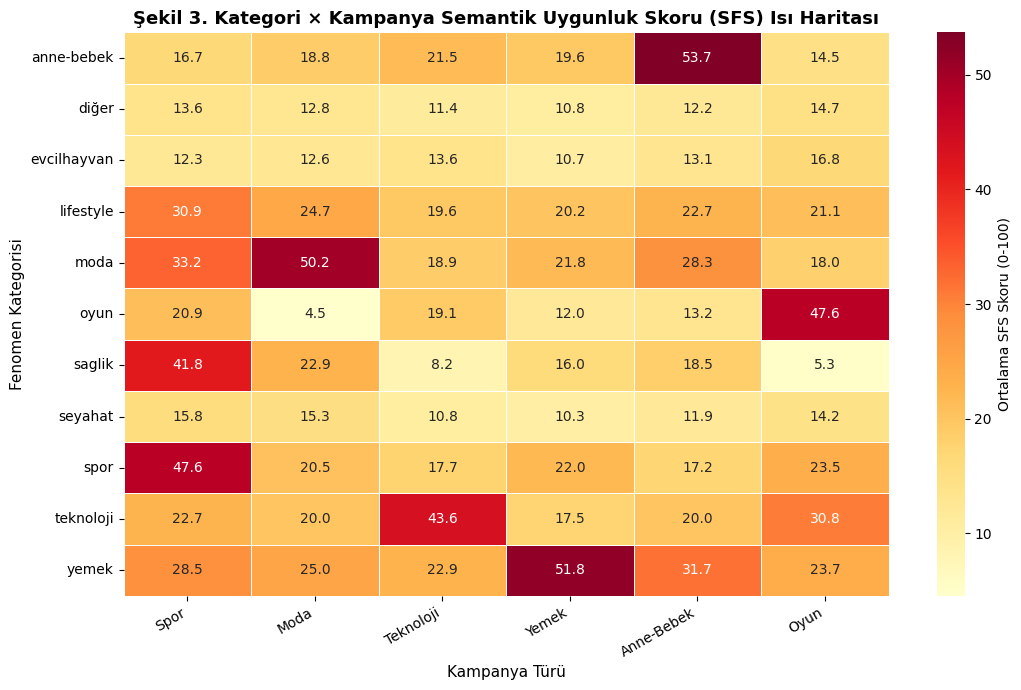

✅ grafik3_sfs_heatmap.png kaydedildi


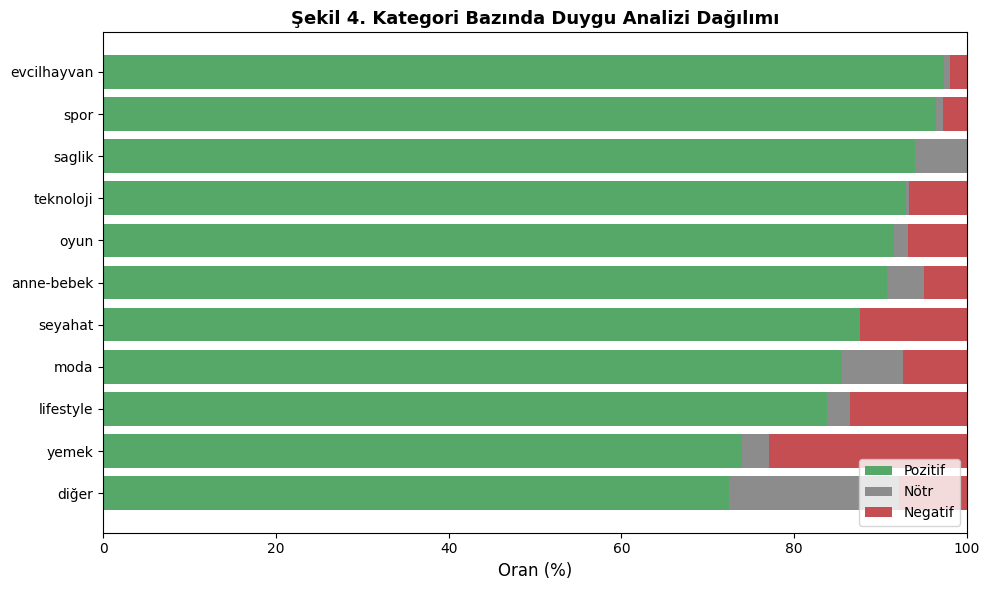

✅ grafik4_duygu_analizi.png kaydedildi


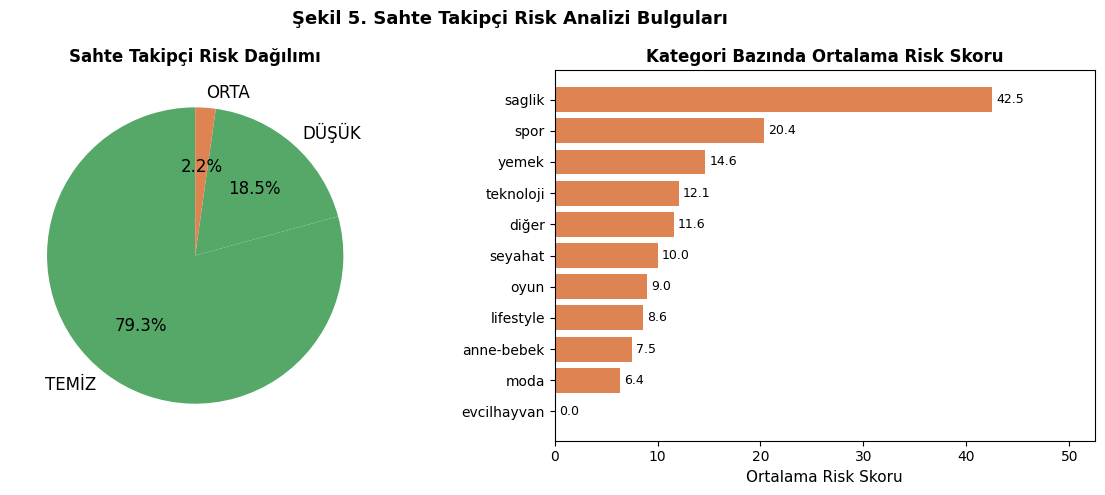

✅ grafik5_sahte_takipci.png kaydedildi


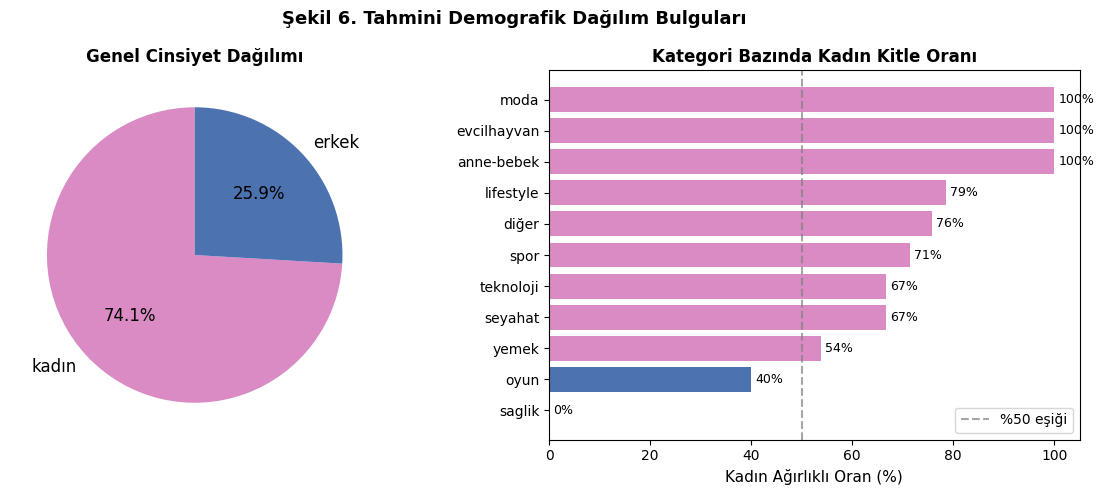

✅ grafik6_demografik.png kaydedildi


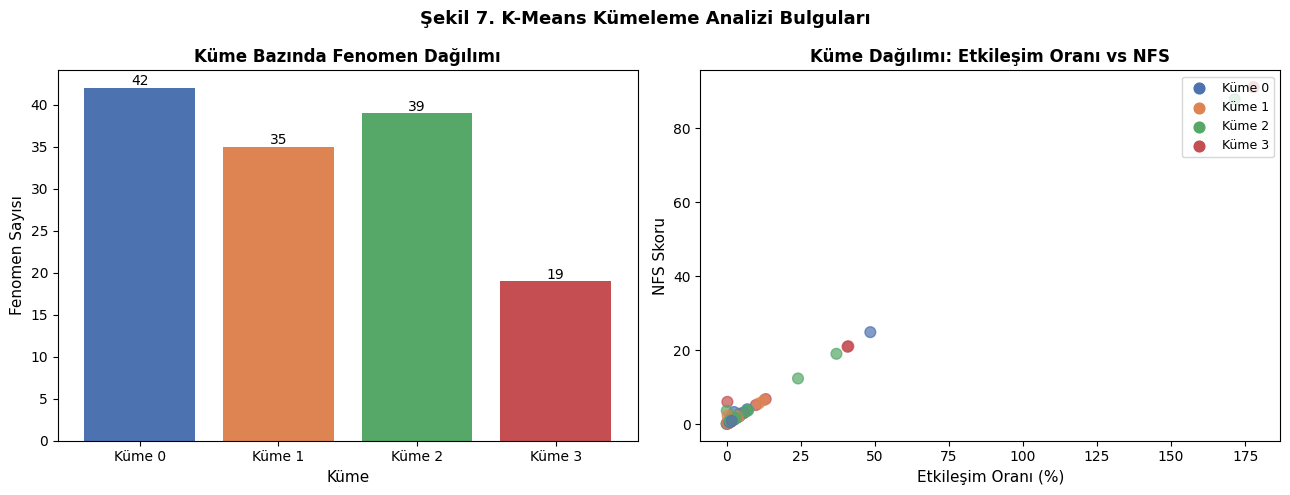

✅ grafik7_kmeans.png kaydedildi


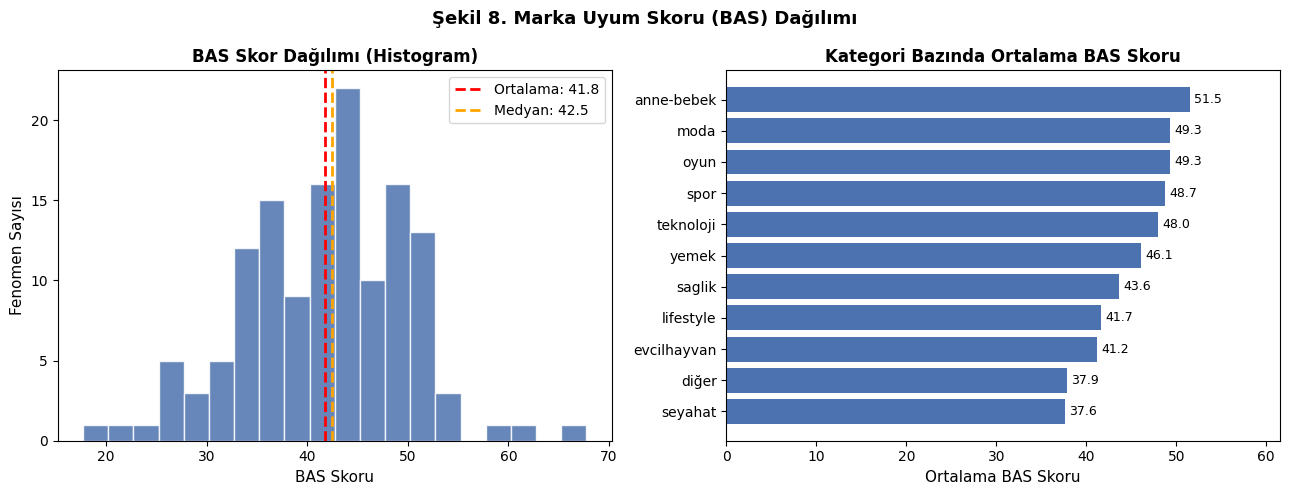

✅ grafik8_bas_dagilimi.png kaydedildi


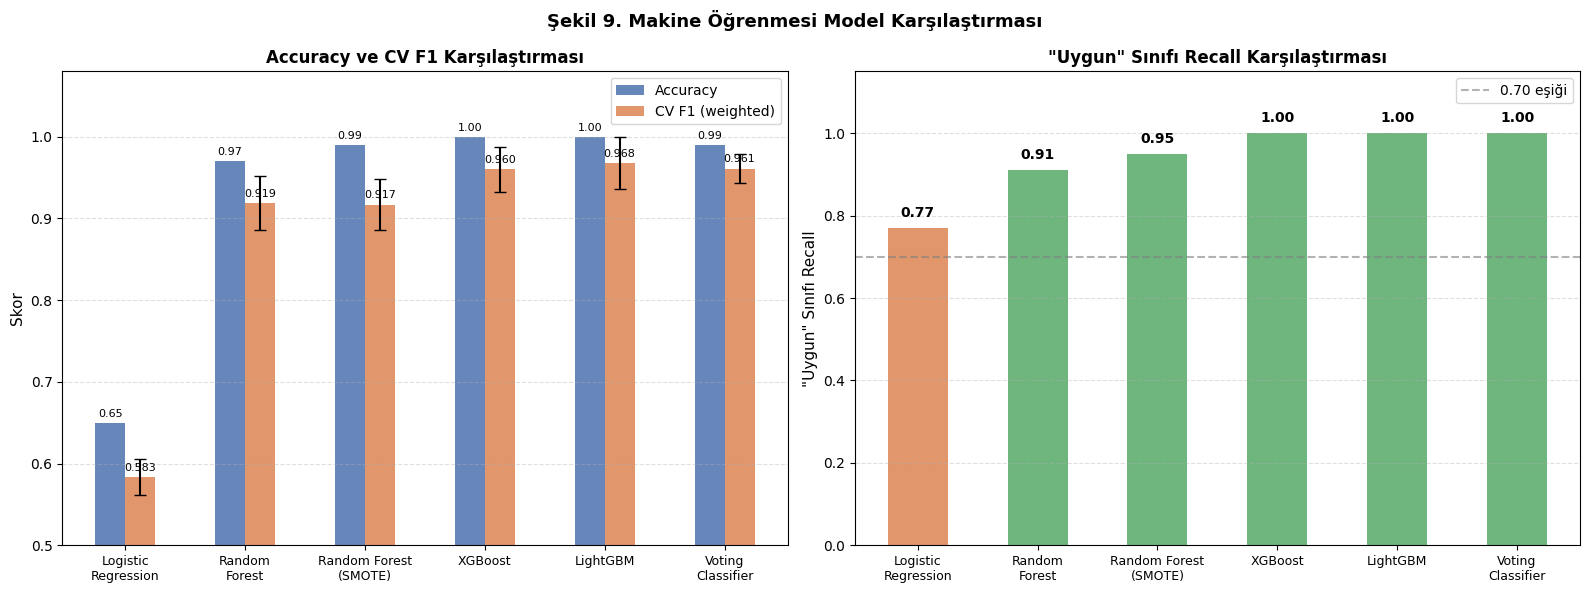

✅ grafik9_model_karsilastirma.png kaydedildi


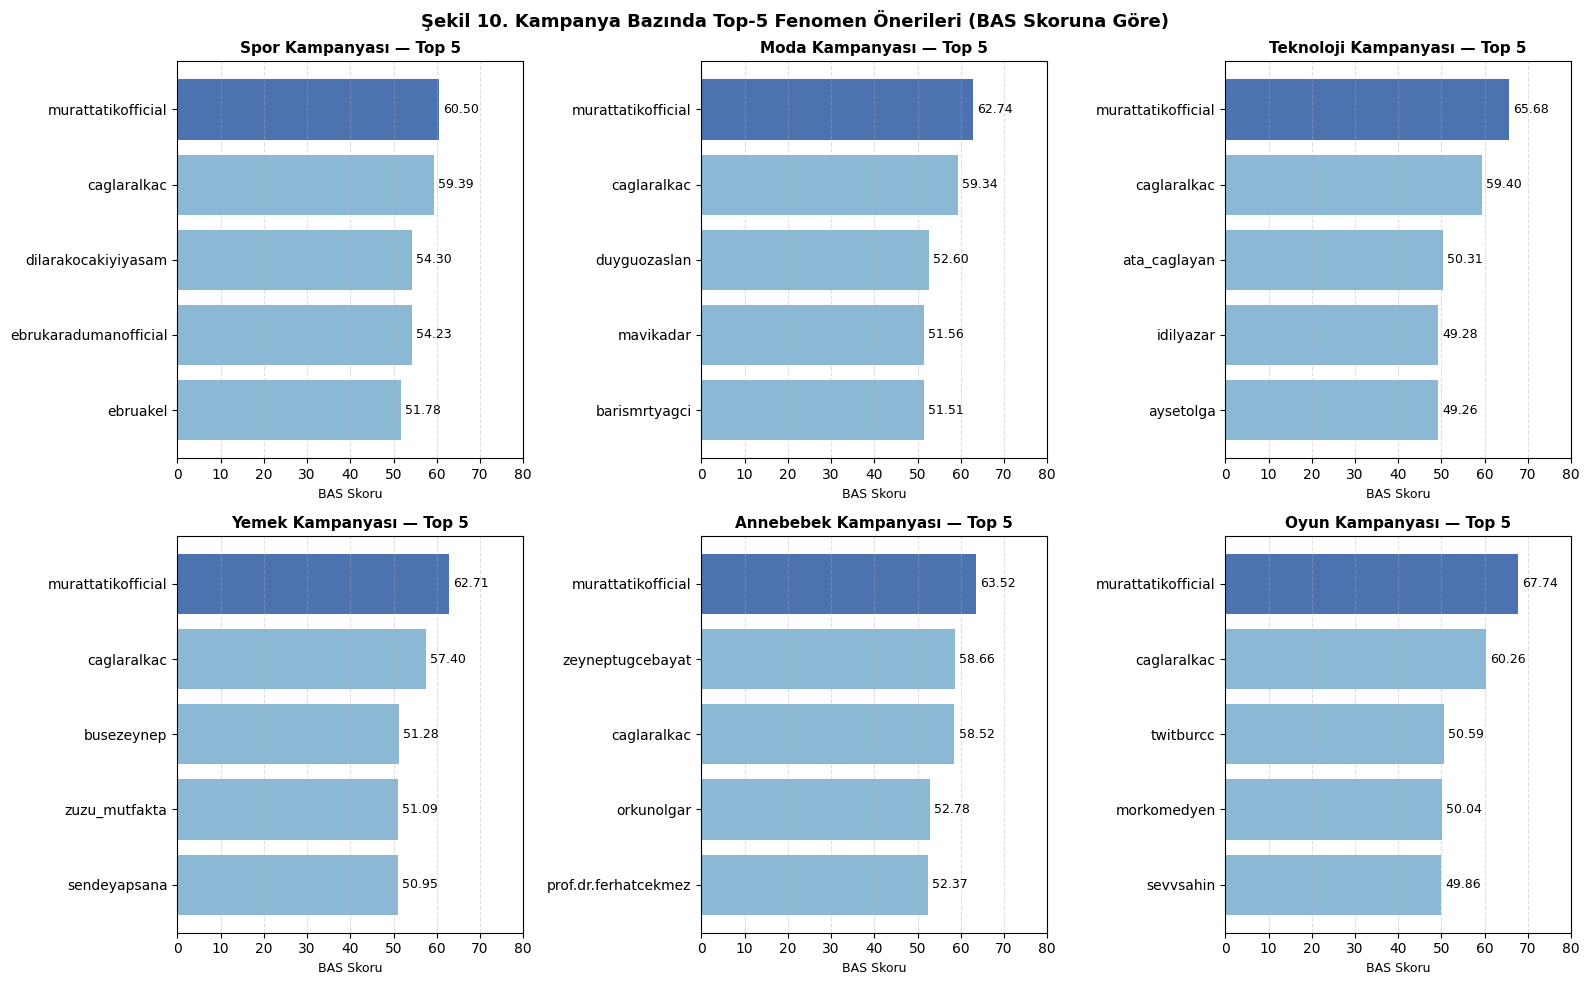

✅ grafik10_top5_oneriler.png kaydedildi

✅ TÜM GRAFİKLER BAŞARIYLA OLUŞTURULDU!


In [68]:
# ============================================================
# BULGULAR GRAFİKLERİ — Tüm grafikleri tek seferde üret ve kaydet
# Her grafik ayrı PNG olarak kaydedilir, rapora eklenebilir
# ============================================================

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False
import warnings
warnings.filterwarnings('ignore')

# Checkpoint'ten yükle
with open('influencer_summary_checkpoint.pkl', 'rb') as f:
    df = pickle.load(f)

print(f"✅ Veri yüklendi: {df.shape[0]} fenomen, {df.shape[1]} sütun")

COLORS = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860','#DA8BC3','#8C8C8C','#CCB974','#64B5CD']

# -------------------------------------------------------
# GRAFİK 1: Kategori bazında fenomen dağılımı
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
cat_counts = df['category'].value_counts().sort_values(ascending=True)
bars = ax.barh(cat_counts.index, cat_counts.values, color=COLORS[:len(cat_counts)])
ax.set_xlabel('Fenomen Sayısı', fontsize=12)
ax.set_title('Şekil 1. Kategori Bazında Fenomen Dağılımı', fontsize=13, fontweight='bold')
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_xlim(0, cat_counts.max() + 5)
plt.tight_layout()
plt.savefig('grafik1_kategori_dagilimi.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ grafik1_kategori_dagilimi.png kaydedildi")

# -------------------------------------------------------
# GRAFİK 2: Kategori bazında ortalama NFS skoru
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
nfs_by_cat = df.groupby('category')['NFS'].mean().sort_values(ascending=True)
bars = ax.barh(nfs_by_cat.index, nfs_by_cat.values, color='#4C72B0')
ax.set_xlabel('Ortalama NFS Skoru', fontsize=12)
ax.set_title('Şekil 2. Kategori Bazında Ortalama Sayısal Uygunluk Skoru (NFS)', fontsize=13, fontweight='bold')
ax.axvline(x=nfs_by_cat.mean(), color='red', linestyle='--', alpha=0.7, label=f'Genel Ortalama: {nfs_by_cat.mean():.1f}')
ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
ax.legend(fontsize=10)
ax.set_xlim(0, nfs_by_cat.max() + 10)
plt.tight_layout()
plt.savefig('grafik2_nfs_kategori.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ grafik2_nfs_kategori.png kaydedildi")

# -------------------------------------------------------
# GRAFİK 3: SFS Isı Haritası
# -------------------------------------------------------
import seaborn as sns
sfs_cols = {
    'Spor':       'sim_spor_kampanyasi',
    'Moda':       'sim_moda_kampanyasi',
    'Teknoloji':  'sim_teknoloji_kampanyasi',
    'Yemek':      'sim_yemek_kampanyasi',
    'Anne-Bebek': 'sim_annebebek_kampanyasi',
    'Oyun':       'sim_oyun_kampanyasi'
}
heatmap_data = pd.DataFrame()
for kampanya_label, col in sfs_cols.items():
    heatmap_data[kampanya_label] = df.groupby('category')[col].mean() * 100

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(
    heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Ortalama SFS Skoru (0-100)'}
)
ax.set_title('Şekil 3. Kategori × Kampanya Semantik Uygunluk Skoru (SFS) Isı Haritası', fontsize=13, fontweight='bold')
ax.set_xlabel('Kampanya Türü', fontsize=11)
ax.set_ylabel('Fenomen Kategorisi', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('grafik3_sfs_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ grafik3_sfs_heatmap.png kaydedildi")

# -------------------------------------------------------
# GRAFİK 4: Duygu analizi
# -------------------------------------------------------
duygu_df = df.groupby('category').agg(
    pozitif=('positive_ratio', 'mean'),
    negatif=('negative_ratio', 'mean')
).reset_index()
duygu_df['notr'] = 100 - duygu_df['pozitif'] - duygu_df['negatif']
duygu_df = duygu_df.sort_values('pozitif', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(duygu_df['category'], duygu_df['pozitif'], color='#55A868', label='Pozitif')
ax.barh(duygu_df['category'], duygu_df['notr'], left=duygu_df['pozitif'], color='#8C8C8C', label='Nötr')
ax.barh(duygu_df['category'], duygu_df['negatif'], left=duygu_df['pozitif']+duygu_df['notr'], color='#C44E52', label='Negatif')
ax.set_xlabel('Oran (%)', fontsize=12)
ax.set_title('Şekil 4. Kategori Bazında Duygu Analizi Dağılımı', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.savefig('grafik4_duygu_analizi.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ grafik4_duygu_analizi.png kaydedildi")

# -------------------------------------------------------
# GRAFİK 5: Sahte takipçi risk
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

risk_counts = df['risk_category'].value_counts()
risk_labels = [r.split(' ')[-1] for r in risk_counts.index]
risk_colors = ['#55A868' if 'TEMİZ' in r or 'DÜŞÜK' in r else '#DD8452' if 'ORTA' in r else '#C44E52' for r in risk_counts.index]

axes[0].pie(risk_counts.values, labels=risk_labels, colors=risk_colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Sahte Takipçi Risk Dağılımı', fontsize=12, fontweight='bold')

risk_by_cat = df.groupby('category')['fake_followers_risk'].mean().sort_values(ascending=True)
bars = axes[1].barh(risk_by_cat.index, risk_by_cat.values, color='#DD8452')
axes[1].set_xlabel('Ortalama Risk Skoru', fontsize=11)
axes[1].set_title('Kategori Bazında Ortalama Risk Skoru', fontsize=12, fontweight='bold')
axes[1].bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
axes[1].set_xlim(0, risk_by_cat.max() + 10)

fig.suptitle('Şekil 5. Sahte Takipçi Risk Analizi Bulguları', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('grafik5_sahte_takipci.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ grafik5_sahte_takipci.png kaydedildi")

# -------------------------------------------------------
# GRAFİK 6: Demografik tahmin
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

gender_counts = df['estimated_gender'].value_counts()
gender_colors = ['#DA8BC3', '#4C72B0']
axes[0].pie(gender_counts.values, labels=gender_counts.index, colors=gender_colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Genel Cinsiyet Dağılımı', fontsize=12, fontweight='bold')

gender_by_cat = df.groupby('category')['estimated_gender'].apply(
    lambda x: (x == 'kadın').sum() / len(x) * 100
).sort_values(ascending=True)
colors_g = ['#DA8BC3' if v >= 50 else '#4C72B0' for v in gender_by_cat.values]
bars = axes[1].barh(gender_by_cat.index, gender_by_cat.values, color=colors_g)
axes[1].axvline(x=50, color='gray', linestyle='--', alpha=0.7, label='%50 eşiği')
axes[1].set_xlabel('Kadın Ağırlıklı Oran (%)', fontsize=11)
axes[1].set_title('Kategori Bazında Kadın Kitle Oranı', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].bar_label(bars, fmt='%.0f%%', padding=3, fontsize=9)

fig.suptitle('Şekil 6. Tahmini Demografik Dağılım Bulguları', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('grafik6_demografik.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ grafik6_demografik.png kaydedildi")

# -------------------------------------------------------
# GRAFİK 7: K-Means kümeleme
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cluster_counts = df['similarity_cluster'].value_counts().sort_index()
axes[0].bar([f'Küme {i}' for i in cluster_counts.index],
            cluster_counts.values, color=COLORS[:len(cluster_counts)])
axes[0].set_xlabel('Küme', fontsize=11)
axes[0].set_ylabel('Fenomen Sayısı', fontsize=11)
axes[0].set_title('Küme Bazında Fenomen Dağılımı', fontsize=12, fontweight='bold')
for i, v in enumerate(cluster_counts.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontsize=10)

scatter_colors = [COLORS[c % len(COLORS)] for c in df['similarity_cluster']]
axes[1].scatter(df['engagement_rate'], df['NFS'], c=scatter_colors, alpha=0.7, s=60)
axes[1].set_xlabel('Etkileşim Oranı (%)', fontsize=11)
axes[1].set_ylabel('NFS Skoru', fontsize=11)
axes[1].set_title('Küme Dağılımı: Etkileşim Oranı vs NFS', fontsize=12, fontweight='bold')
handles = [plt.scatter([], [], color=COLORS[i], label=f'Küme {i}', s=60) for i in range(len(cluster_counts))]
axes[1].legend(handles=handles, fontsize=9, loc='upper right')

fig.suptitle('Şekil 7. K-Means Kümeleme Analizi Bulguları', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('grafik7_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ grafik7_kmeans.png kaydedildi")

# -------------------------------------------------------
# GRAFİK 8: BAS skor dağılımı
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['BAS'], bins=20, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].axvline(df['BAS'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Ortalama: {df["BAS"].mean():.1f}')
axes[0].axvline(df['BAS'].median(), color='orange', linestyle='--', linewidth=2,
                label=f'Medyan: {df["BAS"].median():.1f}')
axes[0].set_xlabel('BAS Skoru', fontsize=11)
axes[0].set_ylabel('Fenomen Sayısı', fontsize=11)
axes[0].set_title('BAS Skor Dağılımı (Histogram)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)

bas_by_cat = df.groupby('category')['BAS'].mean().sort_values(ascending=True)
bars = axes[1].barh(bas_by_cat.index, bas_by_cat.values, color='#4C72B0')
axes[1].set_xlabel('Ortalama BAS Skoru', fontsize=11)
axes[1].set_title('Kategori Bazında Ortalama BAS Skoru', fontsize=12, fontweight='bold')
axes[1].bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
axes[1].set_xlim(0, bas_by_cat.max() + 10)

fig.suptitle('Şekil 8. Marka Uyum Skoru (BAS) Dağılımı', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('grafik8_bas_dagilimi.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ grafik8_bas_dagilimi.png kaydedildi")

# -------------------------------------------------------
# GRAFİK 9: Model karşılaştırma — güncel değerler
# -------------------------------------------------------
model_names  = ['Logistic\nRegression', 'Random\nForest', 'Random Forest\n(SMOTE)',
                'XGBoost', 'LightGBM', 'Voting\nClassifier']
accuracy     = [0.65, 0.97, 0.99, 1.00, 1.00, 0.99]
cv_f1_mean   = [0.583, 0.919, 0.917, 0.960, 0.968, 0.961]
cv_f1_std    = [0.022, 0.033, 0.031, 0.028, 0.032, 0.018]
uygun_recall = [0.77, 0.91, 0.95, 1.00, 1.00, 1.00]

x = np.arange(len(model_names))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars1 = axes[0].bar(x - width/2, accuracy, width, label='Accuracy', color='#4C72B0', alpha=0.85)
bars2 = axes[0].bar(x + width/2, cv_f1_mean, width, label='CV F1 (weighted)', color='#DD8452', alpha=0.85)
axes[0].errorbar(x + width/2, cv_f1_mean, yerr=cv_f1_std,
                 fmt='none', color='black', capsize=4, linewidth=1.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, fontsize=9)
axes[0].set_ylim(0.50, 1.08)
axes[0].set_ylabel('Skor', fontsize=11)
axes[0].set_title('Accuracy ve CV F1 Karşılaştırması', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
for bar in bars1:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

colors_r = ['#C44E52' if r < 0.5 else '#DD8452' if r < 0.8 else '#55A868' for r in uygun_recall]
bars3 = axes[1].bar(x, uygun_recall, width=0.5, color=colors_r, alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, fontsize=9)
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('"Uygun" Sınıfı Recall', fontsize=11)
axes[1].set_title('"Uygun" Sınıfı Recall Karşılaştırması', fontsize=12, fontweight='bold')
axes[1].axhline(y=0.7, color='gray', linestyle='--', alpha=0.6, label='0.70 eşiği')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
for bar in bars3:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

fig.suptitle('Şekil 9. Makine Öğrenmesi Model Karşılaştırması', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('grafik9_model_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ grafik9_model_karsilastirma.png kaydedildi")

# -------------------------------------------------------
# GRAFİK 10: Top-5 kampanya önerileri — gerçek veriden
# -------------------------------------------------------
kampanya_data = {}
for campaign_name, top5_df in all_top5_results.items():
    label = campaign_name.replace('_kampanyasi', '').capitalize()
    kampanya_data[label] = {
        'influencers': top5_df['influencer_name'].tolist(),
        'bas':         top5_df['campaign_bas'].tolist()
    }

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (kampanya, data) in enumerate(kampanya_data.items()):
    influencers = data['influencers'][::-1]
    bas_scores  = data['bas'][::-1]
    bar_colors  = ['#4C72B0' if i == len(influencers)-1 else '#8BB8D4' for i in range(len(influencers))]
    bars = axes[idx].barh(influencers, bas_scores, color=bar_colors)
    axes[idx].set_title(f'{kampanya} Kampanyası — Top 5', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('BAS Skoru', fontsize=9)
    axes[idx].set_xlim(0, 80)
    axes[idx].bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
    axes[idx].grid(axis='x', linestyle='--', alpha=0.4)

fig.suptitle('Şekil 10. Kampanya Bazında Top-5 Fenomen Önerileri (BAS Skoruna Göre)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('grafik10_top5_oneriler.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ grafik10_top5_oneriler.png kaydedildi")

print("\n" + "="*50)
print("✅ TÜM GRAFİKLER BAŞARIYLA OLUŞTURULDU!")
print("="*50)

In [69]:
import pickle

# Eksik sütunları ekle
if 'estimated_gender' not in influencer_summary.columns:
    influencer_summary['estimated_gender'] = 'belirsiz'
if 'risk_category' not in influencer_summary.columns:
    influencer_summary['risk_category'] = 'bilinmiyor'
if 'fake_followers_risk' not in influencer_summary.columns:
    influencer_summary['fake_followers_risk'] = 0
if 'BAS' not in influencer_summary.columns:
    influencer_summary['BAS'] = 0
if 'similarity_cluster' not in influencer_summary.columns:
    influencer_summary['similarity_cluster'] = 0

# Checkpoint'i güncelle
with open('influencer_summary_checkpoint.pkl', 'wb') as f:
    pickle.dump(influencer_summary, f)

print("✅ Checkpoint güncellendi")
print(influencer_summary.columns.tolist())

✅ Checkpoint güncellendi
['influencer_name', 'total_likes', 'total_comments', 'total_shares', 'avg_likes', 'avg_comments', 'avg_views', 'post_count', 'avg_post_reach', 'first_post', 'last_post', 'category', 'country', 'account_type', 'eng_auth', 'engagement_rate', 'FGR', 'day_active', 'posts_per_month', 'latest_followers', 'oldest_followers', 'clean_tags_all', 'engagement_rate_scaled', 'FGR_scaled', 'posts_per_month_scaled', 'nfs_label', 'NFS', 'sim_spor_kampanyasi', 'sim_moda_kampanyasi', 'sim_teknoloji_kampanyasi', 'sim_yemek_kampanyasi', 'sim_annebebek_kampanyasi', 'sim_oyun_kampanyasi', 'positive_ratio_x', 'negative_ratio_x', 'avg_sentiment_score_x', 'avg_signed_sentiment_x', 'positive_ratio_y', 'negative_ratio_y', 'avg_sentiment_score_y', 'avg_signed_sentiment_y', 'positive_ratio', 'negative_ratio', 'avg_sentiment_score', 'avg_signed_sentiment', 'fake_engagement_score', 'fake_growth_score', 'fake_reach_score', 'fake_followers_risk', 'risk_category', 'max_sfs', 'similarity_cluster'

In [70]:
# Notebook'ta şu an aktif olan değerleri yazdır
print("Kampanya sütunları:")
print([c for c in influencer_summary.columns if c.startswith('sim_')])

print("\nKategoriler:")
print(influencer_summary['category'].value_counts())

print("\nAccount type dağılımı:")
print(influencer_summary['account_type'].value_counts())

print("\nÖnemli sütunlar:")
print(influencer_summary[['NFS','BAS','engagement_rate','FGR',
                           'posts_per_month','avg_views',
                           'positive_ratio','avg_signed_sentiment',
                           'fake_followers_risk']].describe().round(2))

Kampanya sütunları:
['sim_spor_kampanyasi', 'sim_moda_kampanyasi', 'sim_teknoloji_kampanyasi', 'sim_yemek_kampanyasi', 'sim_annebebek_kampanyasi', 'sim_oyun_kampanyasi']

Kategoriler:
category
diğer          70
lifestyle      14
yemek          13
moda            9
spor            7
teknoloji       6
oyun            5
anne-bebek      4
evcilhayvan     3
seyahat         3
saglik          1
Name: count, dtype: int64

Account type dağılımı:
account_type
creator     99
business    33
personal     3
Name: count, dtype: int64

Önemli sütunlar:
          NFS     BAS  engagement_rate      FGR  posts_per_month    avg_views  \
count  135.00  135.00           135.00   135.00           135.00       135.00   
mean     3.43   41.77             6.18    56.62            21.28   1966886.37   
std     11.24    8.04            22.00   453.42            69.76   3781901.67   
min      0.09   17.73             0.00   -98.19             0.73         0.00   
25%      0.72   36.53             0.97   -58.70     